# Проект «<span style='color:green'>Стальная птица</span>» уменьшение потребление электроэнергии

# <span style='color:RoyalBlue'>Описание проекта</span>

<span style='font-size:18px'>

Чтобы оптимизировать производственные расходы, металлургический комбинат «`Стальная птица`» решил уменьшить потребление электроэнергии на этапе обработки стали. Для этого комбинату нужно контролировать температуру сплава. Ваша задача — построить модель, которая будет её предсказывать. Заказчик хочет использовать разработанную модель для имитации технологического процесса.

# <span style='color:RoyalBlue'>Цели иследования</span>

<span style='font-size:18px'>

- Построить модель, которая будет предсказывать температуру сплава.
- Испоользовать метрики в проекте `MAE`, `R²`
- MAE должно быть менее `6.8`, дополнительно оценить `R²`.

# <span style='color:RoyalBlue'>Описание процесса обработки</span>

<span style='font-size:18px'>

Сталь обрабатывают в металлическом ковше вместимостью около 100 тонн. Чтобы ковш выдерживал высокие температуры, изнутри его облицовывают огнеупорным кирпичом. Расплавленную сталь заливают в ковш и подогревают до нужной температуры графитовыми электродами. Они установлены на крышке ковша.

Сначала происходит десульфурация — из стали выводят серу и корректируют её химический состав добавлением примесей. Затем сталь легируют — добавляют в неё куски сплава из бункера для сыпучих материалов или порошковую проволоку через специальный трайб-аппарат.

Прежде чем в первый раз ввести легирующие добавки, специалисты производят химический анализ стали и измеряют её температуру. Потом температуру на несколько минут повышают, уже после этого добавляют легирующие материалы и продувают сталь инертным газом, чтобы перемешать, а затем снова проводят измерения. Такой цикл повторяется до тех пор, пока не будут достигнуты нужный химический состав стали и оптимальная температура плавки.

Дальше расплавленная сталь отправляется на доводку металла или поступает в машину непрерывной разливки. Оттуда готовый продукт выходит в виде заготовок-слябов (англ. slab, «плита»).


# <span style='color:RoyalBlue'>Описание данных</span>

<span style='font-size:18px'>

Данные хранятся в Sqlite  — СУБД, в которой база данных представлена одним файлом. Она состоит из нескольких таблиц:

|Таблица|Описание|
|-|-|
|**steel.data_arc**|данные об электродах;|
|**steel.data_bulk**|данные об объёме сыпучих материалов;|
|**steel.data_bulk_time**|данные о времени подачи сыпучих материалов;|
|**steel.data_gas**|данные о продувке сплава газом;|
|**steel.data_temp**|данные об измерениях температуры;|
|**steel.data_wire**|данные об объёме проволочных материалов;|
|**steel.data_wire_time**|данные о времени подачи проволочных материалов.|

<span style="font-size: 18px;">**Таблица: `steel.data_arc` со следующими полями:**</span>

|Поле|Описание|
|-|-|
|**<span style='color:red'>key</span>**|номер партии;|
|**BeginHeat**|время начала нагрева;|
|**EndHeat**|время окончания нагрева;|
|**ActivePower**|значение активной мощности;|
|**ReactivePower**|значение реактивной мощности.|

<span style="font-size: 18px;">**Таблица: `steel.data_bulk` со следующими полями:**</span>

|Поле|Описание|
|-|-|
|**<span style='color:red'>key</span>**|номер партии;|
|**Bulk1 ... Bulk15**|объём подаваемого материала.|

<span style="font-size: 18px;">**Таблица: `steel.data_bulk_time` со следующими полями:**</span>

|Поле|Описание|
|-|-|
|**<span style='color:red'>key</span>**|номер партии;|
|**Bulk1 ... Bulk15**|время подачи материала.|

<span style="font-size: 18px;">**Таблица: `steel.data_gas` со следующими полями:**</span>

|Поле|Описание|
|-|-|
|**<span style='color:red'>key</span>**|номер партии;|
|**gas**|объём подаваемого газа.|

<span style="font-size: 18px;">**Таблица: `steel.data_temp` со следующими полями:**</span>

|Поле|Описание|
|-|-|
|**<span style='color:red'>key</span>**|номер партии;|
|**MesaureTime**|время замера;|
|**<span style='color:green'>Temperature</span>**|значение температуры.|

<span style="font-size: 18px;">**Таблица: `steel.data_wire` со следующими полями:**</span>

|Поле|Описание|
|-|-|
|**<span style='color:red'>key</span>**|номер партии;|
|**Wire1 ...Wire9**|объём подаваемых проволочных материалов.|

<span style="font-size: 18px;">**Таблица: `steel.data_wire_time` со следующими полями:**</span>

|Поле|Описание|
|-|-|
|**<span style='color:red'>key</span>**|номер партии;|
|**Wire1 ...Wire9**|время подачи проволочных материалов.|

<span style='font-size:18px'>

Во всех файлах столбец `key` содержит номер партии. В таблицах может быть несколько строк с одинаковым значением `key`: они соответствуют разным итерациям обработки.

# <span style='color:RoyalBlue'>Содержание</span>

- <span style='font-size: 18px;color: RoyalBlue'>Описание проекта</span>
- <span style='font-size: 18px;color: RoyalBlue'>Цели иследования</span>
- <span style='font-size: 18px;color: RoyalBlue'>Описание процесса обработки</span>
- <span style='font-size: 18px;color: RoyalBlue'>Описание данных</span>
- <span style='font-size: 18px;color: RoyalBlue'>Содержание</span>
- <span style='font-size: 18px;color: Blue'>7. Шаг. Подгруска необходимых модулей и настройка необходимых констант</span>
- <span style='font-size: 18px;color: Blue'>8. Шаг. Загрузка данных</span>
- <span style='font-size: 18px;color: Blue'>9. Шаг. Исследовательский анализ данных</span>
- <span style='font-size: 18px;color: Blue'>10. Шаг. Объедините таблицы по ключу</span>
- <span style='font-size: 18px;color: Blue'>11. Шаг. Подготовьте данные к обучению модели</span>
- <span style='font-size: 18px;color: Blue'>12. Шаг. Обучение лучшей модели</span>
- <span style='font-size: 18px;color: Blue'>13. Шаг. Протестировать модель и продемонстрировать её работу</span>
- <span style='font-size: 18px;color: RoyalBlue'>Итоговые выводы</span>

# <span style='color:Blue'>Шаг. Подгруска необходимых модулей и настройка необходимых констант</span>

## Задача: Подгруска необходимый библиотек.

In [1]:
# Тихая установка нужных библиотек

#!wget https://code.s3.yandex.net/data-scientist/ds-plus-final.db
!pip install matplotlib==3.9.4 -q
!pip install pandas==2.2.3 -q
!pip install seaborn==0.13.2 -q
!pip install numpy==1.23.0 -q
!pip install numba==0.60.0 -q
!pip install shap==0.44.0 -q
!pip install phik==0.12.4 -q
!pip install scikit-learn==1.6.1 -q
!pip install sklearn-compat==0.1.4 -q
!pip install imbalanced-learn==0.12.4 -q
!pip install catboost==1.2.8 -q
!pip install sqlalchemy==2.0.46 -q
!pip install skorch==1.2.0 -q
!pip install optuna==4.8.0 -q
!pip install optuna_integration==4.8.0 -q

#!pip freeze
#!pip list

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scipy 1.9.1 requires numpy<1.25.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
numba 0.56.0 requires numpy<1.23,>=1.18, but you have numpy 2.0.2 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.56.0 requires numpy<1.23,>=1.18, but you have numpy 1.23.0 which is incompatible.


In [2]:
# 1. Стандартные библиотеки Python
import os
import warnings

# 2. Третьи стороны (внешние пакеты)
import phik
import shap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from skorch import NeuralNetRegressor
import optuna
from optuna.integration import OptunaSearchCV

# 3. Библиотеки машинного обучения (pytorch)
import torch
import torch.nn as nn

# 4. Библиотеки машинного обучения (scikit-learn)
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
)

# 5 Библиотеки машинного обучения (catboost)
from catboost import CatBoostRegressor

## Задача: Задаём параметры для рабочего окружения.

In [3]:
# Вывод ошибок
warnings.filterwarnings("ignore", message="Mean of empty slice")
warnings.filterwarnings("ignore", category=RuntimeWarning, module="numpy")
warnings.filterwarnings("ignore", message=".*OptunaSearchCV is experimental.*")
warnings.filterwarnings('ignore', category=UserWarning)

# Отключаем логи Optuna полностью
optuna.logging.set_verbosity(optuna.logging.ERROR)

# Настройки numpy
np.seterr(divide = 'ignore');

# Настройки pandas
pd.options.mode.chained_assignment = None
pd.options.display.float_format = '{:,.4f}'.format

# Укажим целевой признак
target_attribute = 'temperature'

# Задаём основную метрику
METRIC = 'neg_mean_absolute_error'

# Создадим константы
RANDOM_STATE = 270426
TEST_SIZE = 0.25

In [4]:
# Путь к sql базе
#path_to_db = './datasets/ds-plus-final.db' # Локально
path_to_db = 'ds-plus-final.db' # В тетратке яндекс
# Создание подключения
engine = create_engine(f'sqlite:///{path_to_db}', echo=False)

## Задача: Предварительно созданые функции.

### Задача: финкция выполнения запроса SQL.

In [5]:
def completing_requests_sql(query: str):
    """
    Выполянем запрос sqllite
    """
    with engine.connect() as conn:
        request_response = pd.read_sql_query(query, con=conn)
    return request_response

### Задача: финкция вывода первичной информации.

In [6]:
def primary_information_output(dataset):
    # Функция вывод первичной информации
    # Первичная информация
    dataset.info()
    # О пропусках и их доля
    print('Количество пропущеных значений и их доля:')
    number_of_entries = dataset.shape[0]
    preliminary_frame = pd.DataFrame(
        {
            'Наименование признака': [],
            'Количество пропущеных': [],
            'Доля пропущеных': [],
        }
    )
    for key, value in dataset.isna().sum().items():
        preliminary_frame.loc[len(preliminary_frame)] = [
            key,
            value,
            f'{(value / number_of_entries):.2%}',
        ]
    display(preliminary_frame)
    # Информация о полных дублях
    number_of_complete_takes = dataset.duplicated().sum()
    percentage_of_complete_takes = number_of_complete_takes / number_of_entries
    text = 'Количество полных дублированых строк в дата фрейме'
    print(f'{text} = {number_of_complete_takes}, Доля полных дублей = {percentage_of_complete_takes:.1%}')
    # Вывод первых 5 строк фрейма
    display(dataset.head())

### Задача: финкция показа графика нормального распределения.

In [7]:
def plotting_the_normal_distribution(
    df,    # Дата фрейм
    field, # Обрабатываемое поле
    title, # Заголовок графика
    on_the_x_axis, # Под оси Абцыса
    on_the_y_axis, # Под оси Ордината
):
    """
    Построение графика нормального распределания
    """
    sns.histplot(
        data=df,
        x=field,
        kde=True,
    );
    plt.title(title, fontsize=16)
    plt.xlabel(on_the_x_axis)
    plt.ylabel(on_the_y_axis);
    mean_val = np.mean(df[field])
    median_val = np.median(df[field])
    plt.axvline(
        mean_val,
        color='blue',
        linestyle='--',
        linewidth=2,
        label=f'Среднее: {mean_val:.2f}'
    )
    plt.axvline(
        median_val,
        color='deeppink',
        linestyle='-.',
        linewidth=2,
        label=f'Медиана: {median_val:.2f}'
    )
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    #plt.xlim(0, 10000)
    plt.legend()
    plt.show();

### Задача: финкциия показа графика с усами.

In [8]:
def graph_with_a_mustache(
    df,    # Дата фрейм
    field, # Обрабатываемое поле
    title, # Заголовок графика
    on_the_y_axis, # Под оси Абцыса
):
    """
    Строю график с усами
    """
    sns.boxplot(data=df[field])
    plt.title(title)
    plt.ylabel(on_the_y_axis)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

### Задача: финкциия показа графика категориального распределения.

In [9]:
def graph_of_categorical_distribution(
    df,    # Дата фрейм
    field_x, # Показатель по абцисе
    field_y, # Показатель по ордината
    title, # Заголовок графика
    on_the_x_axis, # Под оси Абцыса
    on_the_y_axis, # Под оси Ордината
):
    """
    Строится график по категориальному распределению
    """
    sns.barplot(data=df, x=field_x, y=field_y)
    plt.title(title)
    plt.xlabel(on_the_x_axis)
    plt.ylabel(on_the_y_axis)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show();

### Задача: функции для отрисовки тепловой карты

In [10]:
def heat_map_output(
    data: object,                # Дата фрейм
    list_names_col:dict= None,   # Словарь с претанзиционым наименованием
    number_of_randomness: int=0, # Количество рандомных частей
):
    """
    Функция строит теплавую карту на основании дата фрейма
    """
    if number_of_randomness == 0:
        temp_data = data
    else:
        temp_data = data.sample(number_of_randomness)
    corrective_list = list()
    if list_names_col is None:
        corrective_list = temp_data.columns
    else:
        for x in temp_data.columns:
            corrective_list.append(list_names_col[x])
    temp_data.columns = corrective_list
    quantitative_signs = (
        temp_data.select_dtypes(['float', 'int']).columns.tolist()
    )
    plt.figure(figsize = (16,16))
    plt.title(
        "Теплавая карта коэффициенты корреляции между всеми признаками в дата фрейме\n",
        fontsize =10
    )
    sns.heatmap(
        temp_data.phik_matrix(interval_cols=quantitative_signs),
        annot=True,
        fmt='.2f'
    );

### Задача: Кдасс для вывода ретинга моделей

In [11]:
class RatingBestModels:
    """
    Класс для показа рейтинга моделей с выводом лучших параметров
    """
    
    def __init__(self, X_train, X_test, y_train, y_test):
        """
        Инициализирую параметры
        """
        # Выборки
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        # Список моделей
        self.list_model = []

    def chart_true_vs_predicted(
        self,
        model_name # Искомое имя модели
    ):
        """
        Строит график распределения истиных значений и предсказвных
        """
        for model in self.list_model:
            if model_name == model['name']:
                y_pred = model['model'].predict(self.X_test)     
        plt.scatter(self.y_test, y_pred)
        plt.plot([self.y_test.min(), self.y_test.max()], [self.y_test.min(), self.y_test.max()], 'r--', lw=2)
        plt.title('График распределения истиных значений и предсказвных.')
        plt.xlabel('Истинные значения')
        plt.ylabel('Предсказанные значения')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

    def parameters_of_the_best_model(
        self,
        model_name, # Искомое имя модели
    ):
        """
        Получить значение метрики лучшей модели
        """
        for model in self.list_model:
            if model_name == model['name']:
                print("Параметры Лучшей модели:")
                for param, value in model['model'].best_params_.items():
                    print(f"  {param}: {value}")
                print(f'По метрике MAE лучшей модели на обучающих данных: {round(-model["model"].best_score_, 4)}')
                
    def load(
        self,
        best_model, # Новая модель
        model_name, # Искомое имя новой модели
    ):
        """
        Получаю обученую мадель
        """
        self.list_model.append(
            {
                'name': model_name,
                'model': best_model,
            }
        )

    def best_training_sample_model(self):
        """
        Вывод рейтинка полученых каждой модели на обучающей выборки
        """
        df = pd.DataFrame(
            {'Наименование модели': [], 'METRIC': [], 'TRAIN': []}
        )
        for model in self.list_model:
            # Запись результатов для MAE
            df.loc[len(df)] = [
                model['name'],
                'MAE',
                round(-model['model'].best_score_, 4),
            ]
        return df

    def сompare_results_best_and_constant_models(
        self,
        model_name, # Имя модели
    ):
        """
        Сравните результаты лучшей и константной моделей
        """
        # Создание итоговой таблицы
        df = pd.DataFrame(
            {
                'Наименование модели': [], 
                'METRIC': [], 
                'TRAIN': [], 
                'TEST': []}
        )
        # Создаём и обучаем DummyRegressor с стратегией "mean"
        dummy_reg = DummyRegressor(strategy="mean")
        dummy_reg.fit(self.X_train, self.y_train)
        # Делаем предсказания
        y_pred = dummy_reg.predict(self.X_test)
        # Вывод результатов
        model_const_mae = round(mean_absolute_error(self.y_test, y_pred), 4)
        model_const_r2 = round(r2_score(self.y_test, y_pred), 4)
        # Запись результатов для MAE
        df.loc[len(df)] = [
            'DummyRegressor',
            'MAE',
            '-',
            model_const_mae,
        ]
        # Запись результатов для R²
        df.loc[len(df)] = [
            'DummyRegressor',
            'R²',
            '-',
            model_const_r2,
        ]
        # Запись показателей для лучшей модели
        for model in self.list_model:
            if model_name == model['name']:
                if model['name'] == 'PyTorch':
                    X_test_tensor = torch.tensor(self.X_test.values, dtype=torch.float32)
                    y_pred = model['model'].predict(X_test_tensor)
                else:
                    y_pred = model['model'].predict(self.X_test)
                # Запись результатов для MAE
                df.loc[len(df)] = [
                    model['name'],
                    'MAE',
                    round(-model['model'].best_score_, 4),
                    round(mean_absolute_error(self.y_test, y_pred), 4),
                ]
                # Запись результатов для R²
                df.loc[len(df)] = [
                    model['name'],
                    'R²',
                    '-',
                    round(r2_score(self.y_test, y_pred), 4),
                ]
        return df

# <span style='color:Blue'>Шаг. Загрузка данных</span>

## Задача: Загруска данных с базы sql таблицы: <span style='color:red'>**steel.data_arc**</span>

In [12]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT * 
    FROM data_arc;
    '''
)
# Показываю информацию о дата фрейме
primary_information_output(request_response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   Начало нагрева дугой  14876 non-null  object 
 2   Конец нагрева дугой   14876 non-null  object 
 3   Активная мощность     14876 non-null  float64
 4   Реактивная мощность   14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB
Количество пропущеных значений и их доля:


,Наименование признака,Количество пропущеных,Доля пропущеных
0,key,0,0.00%
1,Начало нагрева дугой,0,0.00%
2,Конец нагрева дугой,0,0.00%
3,Активная мощность,0,0.00%
4,Реактивная мощность,0,0.00%


Количество полных дублированых строк в дата фрейме = 0, Доля полных дублей = 0.0%


,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.3051,0.2113
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.7657,0.4774
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.5803,0.4305
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.5185,0.3800
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.8671,0.6437


**<span style='color:green'>Мини вывод:</span>**

- Поля являются датой (Начало нагрева дугой, Конец нагрева дугой) остальные соответствуют
- Нет пропусков и полных дублей
- Плохо что наименование предоставлены на русском что не соответствует в описание

## Задача: Загруска данных с базы sql таблицы: <span style='color:red'>**steel.data_bulk**</span>

In [13]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT * 
    FROM data_bulk;
    '''
)
# Показываю информацию о дата фрейме
primary_information_output(request_response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   Bulk 1   252 non-null    float64
 2   Bulk 2   22 non-null     float64
 3   Bulk 3   1298 non-null   float64
 4   Bulk 4   1014 non-null   float64
 5   Bulk 5   77 non-null     object 
 6   Bulk 6   576 non-null    object 
 7   Bulk 7   25 non-null     object 
 8   Bulk 8   1 non-null      object 
 9   Bulk 9   19 non-null     object 
 10  Bulk 10  176 non-null    object 
 11  Bulk 11  177 non-null    object 
 12  Bulk 12  2450 non-null   object 
 13  Bulk 13  18 non-null     object 
 14  Bulk 14  2806 non-null   object 
 15  Bulk 15  2248 non-null   object 
dtypes: float64(4), int64(1), object(11)
memory usage: 391.2+ KB
Количество пропущеных значений и их доля:


,Наименование признака,Количество пропущеных,Доля пропущеных
0,key,0,0.00%
1,Bulk 1,2877,91.95%
2,Bulk 2,3107,99.30%
3,Bulk 3,1831,58.52%
4,Bulk 4,2115,67.59%
5,Bulk 5,3052,97.54%
6,Bulk 6,2553,81.59%
7,Bulk 7,3104,99.20%
8,Bulk 8,3128,99.97%
9,Bulk 9,3110,99.39%


Количество полных дублированых строк в дата фрейме = 0, Доля полных дублей = 0.0%


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0000,None,None,None,None,None,None,None,206.0,None,150.0,154.0
1,2,NaN,NaN,NaN,73.0000,None,None,None,None,None,None,None,206.0,None,149.0,154.0
2,3,NaN,NaN,NaN,34.0000,None,None,None,None,None,None,None,205.0,None,152.0,153.0
3,4,NaN,NaN,NaN,81.0000,None,None,None,None,None,None,None,207.0,None,153.0,154.0
4,5,NaN,NaN,NaN,78.0000,None,None,None,None,None,None,None,203.0,None,151.0,152.0


**<span style='color:green'>Мини вывод:</span>**

- Соответствует описаниию колонок
- Нет полных дублей
- Присутствуют пропуски (означает, что материал не добавляли в партию).
- Не соответствуют типу данных начиная `Bulk 5` до `Bulk 15`
- Мало данных в колонках `Bulk 7` - `Bulk 9`
- Меньше пропусков в последних колонках

## Задача: Загруска данных с базы sql таблицы: <span style='color:red'>**steel.data_bulk_time**</span>

In [14]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT * 
    FROM data_bulk_time;
    '''
)
# Показываю информацию о дата фрейме
primary_information_output(request_response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   key      3129 non-null   int64 
 1   Bulk 1   252 non-null    object
 2   Bulk 2   22 non-null     object
 3   Bulk 3   1298 non-null   object
 4   Bulk 4   1014 non-null   object
 5   Bulk 5   77 non-null     object
 6   Bulk 6   576 non-null    object
 7   Bulk 7   25 non-null     object
 8   Bulk 8   1 non-null      object
 9   Bulk 9   19 non-null     object
 10  Bulk 10  176 non-null    object
 11  Bulk 11  177 non-null    object
 12  Bulk 12  2450 non-null   object
 13  Bulk 13  18 non-null     object
 14  Bulk 14  2806 non-null   object
 15  Bulk 15  2248 non-null   object
dtypes: int64(1), object(15)
memory usage: 391.2+ KB
Количество пропущеных значений и их доля:


,Наименование признака,Количество пропущеных,Доля пропущеных
0,key,0,0.00%
1,Bulk 1,2877,91.95%
2,Bulk 2,3107,99.30%
3,Bulk 3,1831,58.52%
4,Bulk 4,2115,67.59%
5,Bulk 5,3052,97.54%
6,Bulk 6,2553,81.59%
7,Bulk 7,3104,99.20%
8,Bulk 8,3128,99.97%
9,Bulk 9,3110,99.39%


Количество полных дублированых строк в дата фрейме = 0, Доля полных дублей = 0.0%


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,None,None,None,2019-05-03 11:28:48,None,None,None,None,None,None,None,2019-05-03 11:24:31,None,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,None,None,None,2019-05-03 11:36:50,None,None,None,None,None,None,None,2019-05-03 11:53:30,None,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,None,None,None,2019-05-03 12:32:39,None,None,None,None,None,None,None,2019-05-03 12:27:13,None,2019-05-03 12:21:01,2019-05-03 12:16:16
3,4,None,None,None,2019-05-03 12:43:22,None,None,None,None,None,None,None,2019-05-03 12:58:00,None,2019-05-03 12:51:11,2019-05-03 12:46:36
4,5,None,None,None,2019-05-03 13:30:47,None,None,None,None,None,None,None,2019-05-03 13:30:47,None,2019-05-03 13:34:12,2019-05-03 13:30:47


**<span style='color:green'>Мини вывод:</span>**

- Соответствует описаниию колонок
- Нет полных дублей
- Присутствуют пропуски
- Не соответствуют типу данных начиная `Bulk 1` до `Bulk 15`
- Меньше пропусков в послендних колонках

## Задача: Загруска данных с базы sql таблицы: <span style='color:red'>**steel.data_gas**</span>

In [15]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT * 
    FROM data_gas;
    '''
)
# Показываю информацию о дата фрейме
primary_information_output(request_response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   Газ 1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB
Количество пропущеных значений и их доля:


,Наименование признака,Количество пропущеных,Доля пропущеных
0,key,0,0.00%
1,Газ 1,0,0.00%


Количество полных дублированых строк в дата фрейме = 0, Доля полных дублей = 0.0%


,key,Газ 1
0,1,29.7500
1,2,12.5556
2,3,28.5548
3,4,18.8412
4,5,5.4137


**<span style='color:green'>Мини вывод:</span>**

- Соответствуют типу данных
- Не соответствует наименование колонкам в описание
- Нет пропусков и полных дублей 

## Задача: Загруска данных с базы sql таблицы: <span style='color:red'>**steel.data_temp**</span>

In [16]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT * 
    FROM data_temp;
    '''
)
# Показываю информацию о дата фрейме
primary_information_output(request_response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   key           18092 non-null  int64 
 1   Время замера  18092 non-null  object
 2   Температура   14665 non-null  object
dtypes: int64(1), object(2)
memory usage: 424.2+ KB
Количество пропущеных значений и их доля:


,Наименование признака,Количество пропущеных,Доля пропущеных
0,key,0,0.00%
1,Время замера,0,0.00%
2,Температура,3427,18.94%


Количество полных дублированых строк в дата фрейме = 0, Доля полных дублей = 0.0%


,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0
3,1,2019-05-03 11:18:04,1601.0
4,1,2019-05-03 11:25:59,1606.0


**<span style='color:green'>Мини вывод:</span>**

- Не соответствуют пипу данных
- Наименование колонок не соответствуют описанию (На русском)
- Есть пропуски по полю температура (Можно заполнить медианой если нет сильных выбросов)
- Полных дублей нет

## Задача: Загруска данных с базы sql таблицы: <span style='color:red'>**steel.data_wire**</span>

In [17]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT * 
    FROM data_wire;
    '''
)
# Показываю информацию о дата фрейме
primary_information_output(request_response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   Wire 1  3055 non-null   float64
 2   Wire 2  1079 non-null   object 
 3   Wire 3  63 non-null     object 
 4   Wire 4  14 non-null     object 
 5   Wire 5  1 non-null      object 
 6   Wire 6  73 non-null     object 
 7   Wire 7  11 non-null     object 
 8   Wire 8  19 non-null     object 
 9   Wire 9  29 non-null     object 
dtypes: float64(1), int64(1), object(8)
memory usage: 240.8+ KB
Количество пропущеных значений и их доля:


,Наименование признака,Количество пропущеных,Доля пропущеных
0,key,0,0.00%
1,Wire 1,26,0.84%
2,Wire 2,2002,64.98%
3,Wire 3,3018,97.96%
4,Wire 4,3067,99.55%
5,Wire 5,3080,99.97%
6,Wire 6,3008,97.63%
7,Wire 7,3070,99.64%
8,Wire 8,3062,99.38%
9,Wire 9,3052,99.06%


Количество полных дублированых строк в дата фрейме = 0, Доля полных дублей = 0.0%


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.0600,None,None,None,None,None,None,None,None
1,2,96.0523,None,None,None,None,None,None,None,None
2,3,91.1602,None,None,None,None,None,None,None,None
3,4,89.0635,None,None,None,None,None,None,None,None
4,5,89.2382,9.11456,None,None,None,None,None,None,None


**<span style='color:green'>Мини вывод:</span>**

- С `Wire 2` по `Wire 9`  не соответствуют типу данных
- Наименование колонок совпадает с описание
- Нет полных дублей
- Присутствуют пропуски

## Задача: Загруска данных с базы sql таблицы: <span style='color:red'>**steel.data_wire_time**</span>

In [18]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT * 
    FROM data_wire_time;
    '''
)
# Показываю информацию о дата фрейме
primary_information_output(request_response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   key     3081 non-null   int64 
 1   Wire 1  3055 non-null   object
 2   Wire 2  1079 non-null   object
 3   Wire 3  63 non-null     object
 4   Wire 4  14 non-null     object
 5   Wire 5  1 non-null      object
 6   Wire 6  73 non-null     object
 7   Wire 7  11 non-null     object
 8   Wire 8  19 non-null     object
 9   Wire 9  29 non-null     object
dtypes: int64(1), object(9)
memory usage: 240.8+ KB
Количество пропущеных значений и их доля:


,Наименование признака,Количество пропущеных,Доля пропущеных
0,key,0,0.00%
1,Wire 1,26,0.84%
2,Wire 2,2002,64.98%
3,Wire 3,3018,97.96%
4,Wire 4,3067,99.55%
5,Wire 5,3080,99.97%
6,Wire 6,3008,97.63%
7,Wire 7,3070,99.64%
8,Wire 8,3062,99.38%
9,Wire 9,3052,99.06%


Количество полных дублированых строк в дата фрейме = 0, Доля полных дублей = 0.0%


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:06:19,None,None,None,None,None,None,None,None
1,2,2019-05-03 11:36:50,None,None,None,None,None,None,None,None
2,3,2019-05-03 12:11:46,None,None,None,None,None,None,None,None
3,4,2019-05-03 12:43:22,None,None,None,None,None,None,None,None
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,None,None,None,None,None,None,None


**<span style='color:green'>Мини вывод:</span>**

- Описание колонок сооттветствует
- Нет полных дублей
- Присутствуют пропуски
- Не соответствуют типу данных с `Wire 1` по `Wire 9`

**<span style='color:Orange'>Вывод шага:</span>**

- Есть таблици где очень много пропуско в и восновном связанно с отсутствия значений для присвоения
- Также есть не соответствия типам данных
- Страдает наименование колонок не соответствует описанию
- Хранология заполнения тоже страдает
- Полных дублей как таковой нет

# <span style='color:Blue'>Шаг. Исследовательский анализ данных</span>

## Задача: Проанализируем исходные данные.

In [19]:
# Получаем список всех таблиц
with engine.connect() as conn:
    # Запрос к системной таблице SQLite
    tables_query = "SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%';"
    tables = pd.read_sql_query(tables_query, con=conn)['name'].tolist()

    # Собираем статистику по каждой таблице
    results = []
    for table in tables:
        # Используем text() для безопасности и f-строку для имени таблицы
        count_query = text(f"SELECT count(*) as cnt FROM {table}")
        count = conn.execute(count_query).scalar()
        
        results.append({
            'table_name': table,
            'rows_count': count,
            'is_empty': count == 0
        })

# Выводим результат в удобном виде DataFrame
request_response = pd.DataFrame(results)
request_response.columns = ['Имя таблицы', 'Количество записей', 'Пустая или нет']
# Вывод полученного запроса
request_response.sort_values(by='Количество записей', ascending=False)

,Имя таблицы,Количество записей,Пустая или нет
9,data_temp,18092,False
0,data_arc,14876,False
4,contract,7043,False
5,personal,7043,False
6,phone,6361,False
7,internet,5517,False
8,data_gas,3239,False
1,data_bulk,3129,False
2,data_bulk_time,3129,False
3,data_wire_time,3081,False


**<span style='color:green'>Мини вывод:</span>**

- В Описание нет даных о Следующих таблицах:
    - `contract`
    - `personal`
    - `phone` 
    - `internet`
- Нужно сообщить заказчику о не описаных колонках в предоставленых данных а пока приостановить работы сним
- Список перечисленых колонак очень рисковый для бизнаса
- Все таблицы имеют данные

## Задача: Загруска данных с базы sql таблицы: <span style='color:red'>**steel.data_arc**</span>

In [20]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT * 
    FROM data_arc;
    '''
)
# Показываю информацию о дата фрейме
primary_information_output(request_response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   Начало нагрева дугой  14876 non-null  object 
 2   Конец нагрева дугой   14876 non-null  object 
 3   Активная мощность     14876 non-null  float64
 4   Реактивная мощность   14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB
Количество пропущеных значений и их доля:


,Наименование признака,Количество пропущеных,Доля пропущеных
0,key,0,0.00%
1,Начало нагрева дугой,0,0.00%
2,Конец нагрева дугой,0,0.00%
3,Активная мощность,0,0.00%
4,Реактивная мощность,0,0.00%


Количество полных дублированых строк в дата фрейме = 0, Доля полных дублей = 0.0%


,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.3051,0.2113
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.7657,0.4774
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.5803,0.4305
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.5185,0.3800
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.8671,0.6437


### Задача: Проверка на пропуски (Если пропусков нет будет нули)

In [21]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT 
        SUM(CASE WHEN "Начало нагрева дугой" IS NULL THEN 1 ELSE 0 END) AS BeginHeat,
        SUM(CASE WHEN "Конец нагрева дугой" IS NULL THEN 1 ELSE 0 END) AS EndHeat,
        SUM(CASE WHEN "Активная мощность" IS NULL THEN 1 ELSE 0 END) AS ActivePower,
        SUM(CASE WHEN "Реактивная мощность" IS NULL THEN 1 ELSE 0 END) AS ReactivePower
    FROM data_arc;
    '''
)
# Вывод запроса
request_response

,BeginHeat,EndHeat,ActivePower,ReactivePower
0,0,0,0,0


**<span style='color:green'>Мини вывод:</span>**

- Пропуски отсутствуют у всех колонках

### Задача: Смотрим графики по числовым показателям

In [22]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT "Активная мощность",	"Реактивная мощность"
    FROM data_arc;
    '''
)
# Показываю информацию о дата фрейме
primary_information_output(request_response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Активная мощность    14876 non-null  float64
 1   Реактивная мощность  14876 non-null  float64
dtypes: float64(2)
memory usage: 232.6 KB
Количество пропущеных значений и их доля:


,Наименование признака,Количество пропущеных,Доля пропущеных
0,Активная мощность,0,0.00%
1,Реактивная мощность,0,0.00%


Количество полных дублированых строк в дата фрейме = 0, Доля полных дублей = 0.0%


,Активная мощность,Реактивная мощность
0,0.3051,0.2113
1,0.7657,0.4774
2,0.5803,0.4305
3,0.5185,0.3800
4,0.8671,0.6437


In [23]:
# Вывод основныхз показателей количественных данных
request_response.describe()

,Активная мощность,Реактивная мощность
count,"14,876.0000","14,876.0000"
mean,0.6628,0.4390
std,0.2589,5.8735
min,0.2231,-715.4799
25%,0.4671,0.3372
50%,0.5996,0.4416
75%,0.8301,0.6082
max,1.4638,1.2703


**<span style='color:red'>Колонка:</span> Активная мощность**

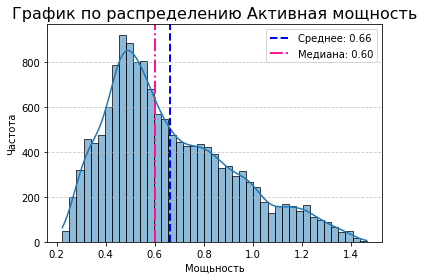

In [24]:
# Построение графика
plotting_the_normal_distribution(
    request_response,
    'Активная мощность',
    'График по распределению Активная мощность',
    'Мощьность',
    'Частота',
)

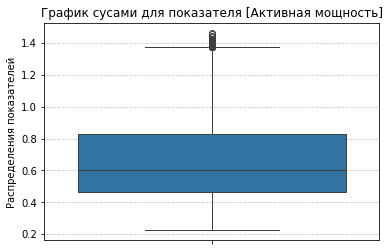

In [25]:
# Строим график
graph_with_a_mustache(
    request_response,
    'Активная мощность',
    'График сусами для показателя [Активная мощность]',
    'Распределения показателей',
)

**<span style='color:red'>Колонка:</span> Реактивная мощность**

In [26]:
# Убрать лишние значения
request_response = request_response.loc[request_response['Реактивная мощность'] > -700]

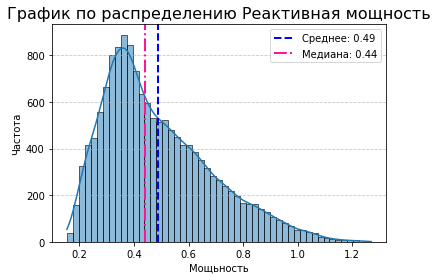

In [27]:
# Построение графика
plotting_the_normal_distribution(
    request_response,
    'Реактивная мощность',
    'График по распределению Реактивная мощность',
    'Мощьность',
    'Частота',
)

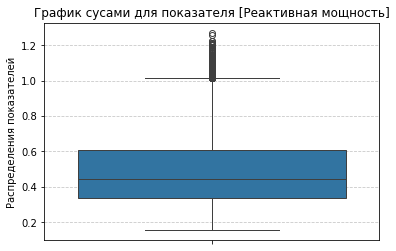

In [28]:
# Строим график
graph_with_a_mustache(
    request_response,
    'Реактивная мощность',
    'График сусами для показателя [Реактивная мощность]',
    'Распределения показателей',
)

**<span style='color:green'>Мини вывод:</span>**

- Присутствуют выбрасы в колонках [Активная мощность, Реактивная мощность]
- В `Активная мощность` - максимальных значениях после `Q3` Квартиль 
- В `Реактивная мощность` - минимальное значение после `Q1` Квартиль
- При формирование тренировачной выборки стоит учесть данных аспект
- [Активная мощность, Реактивная мощность] Очень похожи графики в расхождении гдето `0.2`

### Задача: Проверим не выходит ли начало поже конца нагрева дугой

In [29]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT COUNT(*) AS "Количество начало больше конца нагрева дугой"
    FROM data_arc
    WHERE datetime("Начало нагрева дугой") > datetime("Конец нагрева дугой");
    '''
)
# Вывод запроса
request_response

,Количество начало больше конца нагрева дугой
0,0


**<span style='color:green'>Мини вывод:</span>**

- Получается данные записаны как минемум не перехлёстываются

### Задача: Создание новых признаков

#### Задача: Признак [Длительность нагрева]

<span style='font-size:18px'>

- Признак:  **<span style='color:DarkBlue'>Длительность нагрева</span>**
- Описание: Получаем методом разности между [Конец нагрева дугой - Начало нагрева дугой]	

In [30]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT 
        (julianday(datetime("Конец нагрева дугой")) - julianday(datetime("Начало нагрева дугой"))) * 86400 AS "Длительность нагрева"
    FROM data_arc;
    '''
)
# Показываю информацию о дата фрейме
primary_information_output(request_response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 1 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Длительность нагрева  14876 non-null  float64
dtypes: float64(1)
memory usage: 116.3 KB
Количество пропущеных значений и их доля:


,Наименование признака,Количество пропущеных,Доля пропущеных
0,Длительность нагрева,0,0.00%


Количество полных дублированых строк в дата фрейме = 13896, Доля полных дублей = 93.4%


,Длительность нагрева
0,228.0000
1,185.0000
2,172.0000
3,365.0000
4,148.0000


In [31]:
# Основные показатели
request_response['Длительность нагрева'].describe()

count   14,876.0000
mean       171.6709
std         98.1868
min         11.0000
25%        107.0000
50%        147.0000
75%        214.0000
max        907.0000
Name: Длительность нагрева, dtype: float64

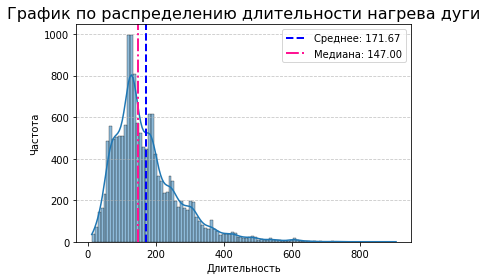

In [32]:
# Построение графика
plotting_the_normal_distribution(
    request_response,
    'Длительность нагрева',
    'График по распределению длительности нагрева дуги',
    'Длительность',
    'Частота',
)

**<span style='color:green'>Мини вывод:</span>**

- Пик находится в раёне 120
- Основная доля находится в диапазоне от 11 до 350 значений
- Не сильно отличается медиана с средним
- Длительность нагрева очень часто повторяется в полных дублей

#### Задача: Признак [Общую мощность]

<span style='font-size:18px'>

- Признак:  **<span style='color:DarkBlue'>Общую мощность</span>**
- Описание: Получаем методом сложения между [Активная мощность + Реактивная мощность]	

In [33]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT 
        "Активная мощность" + "Реактивная мощность" AS "Общая мощность"
    FROM data_arc;
    '''
)
# Показываю информацию о дата фрейме
primary_information_output(request_response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Общая мощность  14876 non-null  float64
dtypes: float64(1)
memory usage: 116.3 KB
Количество пропущеных значений и их доля:


,Наименование признака,Количество пропущеных,Доля пропущеных
0,Общая мощность,0,0.00%


Количество полных дублированых строк в дата фрейме = 73, Доля полных дублей = 0.5%


,Общая мощность
0,0.5164
1,1.2431
2,1.0108
3,0.8985
4,1.5108


In [34]:
# Основные показатели
request_response['Общая мощность'].describe()

count   14,876.0000
mean         1.1017
std          5.8872
min       -714.7746
25%          0.8073
50%          1.0436
75%          1.4382
max          2.6807
Name: Общая мощность, dtype: float64

In [35]:
# Убрать лишние значения
request_response = request_response.loc[request_response['Общая мощность'] > -700]

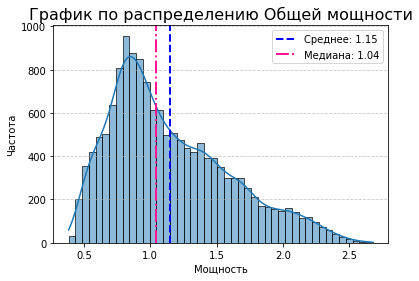

In [36]:
# Построение графика
plotting_the_normal_distribution(
    request_response,
    'Общая мощность',
    'График по распределению Общей мощности',
    'Мощность',
    'Частота',
)

**<span style='color:green'>Мини вывод:</span>**

- Присутствует выброс минимального значение в `-714` что мешает построить график
- Пик находится на `0.8`
- Чем выше общая мощьность тем ниже частота его появления
- После пика показатели растягиваются
- Мощьность сильно разнообразна в показателях

#### Задача: Признак [Соотношение мощности]

<span style='font-size:18px'>

- Признак:  **<span style='color:DarkBlue'>Соотношение мощности</span>**
- Описание: Получаем методом деление между [Активная мощность / Реактивная мощность]	

In [37]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT 
        "Активная мощность" / "Реактивная мощность" AS "Соотношение мощности"
    FROM data_arc;
    '''
)
# Показываю информацию о дата фрейме
primary_information_output(request_response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 1 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Соотношение мощности  14876 non-null  float64
dtypes: float64(1)
memory usage: 116.3 KB
Количество пропущеных значений и их доля:


,Наименование признака,Количество пропущеных,Доля пропущеных
0,Соотношение мощности,0,0.00%


Количество полных дублированых строк в дата фрейме = 0, Доля полных дублей = 0.0%


,Соотношение мощности
0,1.4444
1,1.6037
2,1.3481
3,1.3645
4,1.3471


In [38]:
# Основные показатели
request_response['Соотношение мощности'].describe()

count   14,876.0000
mean         1.3734
std          0.1314
min         -0.0010
25%          1.2801
50%          1.3798
75%          1.4712
max          1.8574
Name: Соотношение мощности, dtype: float64

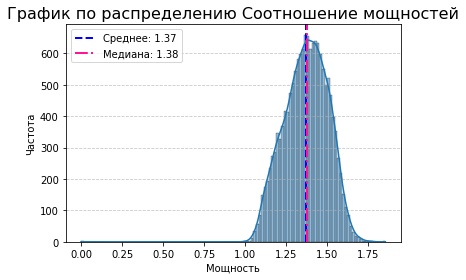

In [39]:
# Построение графика
plotting_the_normal_distribution(
    request_response,
    'Соотношение мощности',
    'График по распределению Соотношение мощностей',
    'Мощность',
    'Частота',
)

**<span style='color:green'>Мини вывод:</span>**

- Основные значения формируются вокруг диапазона от `1` по `1.75`
- Мединана с средний практически схожи
- У графика нет растянутости из сторон
- Показатель разообразный

#### Задача: Признак [Количество запуска нагрева электродами]

<span style='font-size:18px'>

- Признак:  **<span style='color:DarkBlue'>Количество запуска нагрева электродами</span>**
- Описание: Получаем методом подсчёта количество сгрупирированый по полю `key`

In [40]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT 
        key, COUNT(*) AS "Количество запусков"
    FROM data_arc
    GROUP BY key;
    '''
)
# Показываю информацию о дата фрейме
primary_information_output(request_response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   key                  3214 non-null   int64
 1   Количество запусков  3214 non-null   int64
dtypes: int64(2)
memory usage: 50.3 KB
Количество пропущеных значений и их доля:


,Наименование признака,Количество пропущеных,Доля пропущеных
0,key,0,0.00%
1,Количество запусков,0,0.00%


Количество полных дублированых строк в дата фрейме = 0, Доля полных дублей = 0.0%


,key,Количество запусков
0,1,5
1,2,4
2,3,5
3,4,4
4,5,4


In [41]:
# Основные показатели
request_response['Количество запусков'].describe()

count   3,214.0000
mean        4.6285
std         1.6086
min         1.0000
25%         4.0000
50%         4.0000
75%         6.0000
max        16.0000
Name: Количество запусков, dtype: float64

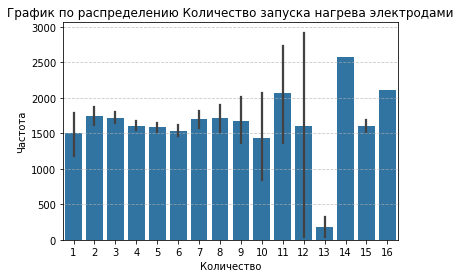

In [42]:
# Строю график
graph_of_categorical_distribution(
    request_response,
    'Количество запусков',
    'key',
    'График по распределению Количество запуска нагрева электродами',
    'Количество',
    'Частота',
)

**<span style='color:green'>Мини вывод:</span>**

- Если нагревание больше `9` запусков начинаетс нестабильность
- Практически все вышке стремятся в частоте `1500` или около
- В среднем количество запусков `4` стремящиеся к `5`

## Задача: Анализ таблицы: <span style='color:red'>steel.data_bulk</span>.

In [43]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT * 
    FROM data_bulk;
    '''
)
# Показываю информацию о дата фрейме
primary_information_output(request_response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   Bulk 1   252 non-null    float64
 2   Bulk 2   22 non-null     float64
 3   Bulk 3   1298 non-null   float64
 4   Bulk 4   1014 non-null   float64
 5   Bulk 5   77 non-null     object 
 6   Bulk 6   576 non-null    object 
 7   Bulk 7   25 non-null     object 
 8   Bulk 8   1 non-null      object 
 9   Bulk 9   19 non-null     object 
 10  Bulk 10  176 non-null    object 
 11  Bulk 11  177 non-null    object 
 12  Bulk 12  2450 non-null   object 
 13  Bulk 13  18 non-null     object 
 14  Bulk 14  2806 non-null   object 
 15  Bulk 15  2248 non-null   object 
dtypes: float64(4), int64(1), object(11)
memory usage: 391.2+ KB
Количество пропущеных значений и их доля:


,Наименование признака,Количество пропущеных,Доля пропущеных
0,key,0,0.00%
1,Bulk 1,2877,91.95%
2,Bulk 2,3107,99.30%
3,Bulk 3,1831,58.52%
4,Bulk 4,2115,67.59%
5,Bulk 5,3052,97.54%
6,Bulk 6,2553,81.59%
7,Bulk 7,3104,99.20%
8,Bulk 8,3128,99.97%
9,Bulk 9,3110,99.39%


Количество полных дублированых строк в дата фрейме = 0, Доля полных дублей = 0.0%


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0000,None,None,None,None,None,None,None,206.0,None,150.0,154.0
1,2,NaN,NaN,NaN,73.0000,None,None,None,None,None,None,None,206.0,None,149.0,154.0
2,3,NaN,NaN,NaN,34.0000,None,None,None,None,None,None,None,205.0,None,152.0,153.0
3,4,NaN,NaN,NaN,81.0000,None,None,None,None,None,None,None,207.0,None,153.0,154.0
4,5,NaN,NaN,NaN,78.0000,None,None,None,None,None,None,None,203.0,None,151.0,152.0


### Задача: Проверка на пропуски (Если пропусков нет будет нули).

In [44]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT 
        SUM(CASE WHEN "Bulk 1" IS NULL THEN 1 ELSE 0 END) AS B1,
        SUM(CASE WHEN "Bulk 2" IS NULL THEN 1 ELSE 0 END) AS B2,
        SUM(CASE WHEN "Bulk 3" IS NULL THEN 1 ELSE 0 END) AS B3,
        SUM(CASE WHEN "Bulk 4" IS NULL THEN 1 ELSE 0 END) AS B4,
        SUM(CASE WHEN "Bulk 5" IS NULL THEN 1 ELSE 0 END) AS B5,
        SUM(CASE WHEN "Bulk 6" IS NULL THEN 1 ELSE 0 END) AS B6,
        SUM(CASE WHEN "Bulk 7" IS NULL THEN 1 ELSE 0 END) AS B7,
        SUM(CASE WHEN "Bulk 8" IS NULL THEN 1 ELSE 0 END) AS B8,
        SUM(CASE WHEN "Bulk 9" IS NULL THEN 1 ELSE 0 END) AS B9,
        SUM(CASE WHEN "Bulk 10" IS NULL THEN 1 ELSE 0 END) AS B10,
        SUM(CASE WHEN "Bulk 11" IS NULL THEN 1 ELSE 0 END) AS B11,
        SUM(CASE WHEN "Bulk 12" IS NULL THEN 1 ELSE 0 END) AS B12,
        SUM(CASE WHEN "Bulk 13" IS NULL THEN 1 ELSE 0 END) AS B13,
        SUM(CASE WHEN "Bulk 14" IS NULL THEN 1 ELSE 0 END) AS B14,
        SUM(CASE WHEN "Bulk 15" IS NULL THEN 1 ELSE 0 END) AS B15
    FROM data_bulk;
    '''
)
# Вывод запроса
request_response

,B1,B2,B3,B4,B5,B6,B7,B8,B9,B10,B11,B12,B13,B14,B15
0,2877,3107,1831,2115,3052,2553,3104,3128,3110,2953,2952,679,3111,323,881


### Задача: Запросим основные показатели.

In [45]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT *
    FROM data_bulk;
    '''
)
# Вывод запроса
request_response

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0000,None,None,None,None,None,None,None,206.0,None,150.0,154.0
1,2,NaN,NaN,NaN,73.0000,None,None,None,None,None,None,None,206.0,None,149.0,154.0
2,3,NaN,NaN,NaN,34.0000,None,None,None,None,None,None,None,205.0,None,152.0,153.0
3,4,NaN,NaN,NaN,81.0000,None,None,None,None,None,None,None,207.0,None,153.0,154.0
4,5,NaN,NaN,NaN,78.0000,None,None,None,None,None,None,None,203.0,None,151.0,152.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3124,3237,NaN,NaN,170.0000,NaN,None,None,None,None,None,None,None,252.0,None,130.0,206.0
3125,3238,NaN,NaN,126.0000,NaN,None,None,None,None,None,None,None,254.0,None,108.0,106.0
3126,3239,NaN,NaN,NaN,NaN,None,114.0,None,None,None,None,None,158.0,None,270.0,88.0
3127,3240,NaN,NaN,NaN,NaN,None,26.0,None,None,None,None,None,None,None,192.0,54.0


In [46]:
# Выборка полей
selected_fields = request_response.columns.tolist()
selected_fields = selected_fields[1:]
# Изменение типа нескольких столбцов
request_response[selected_fields] = request_response[selected_fields].astype(float)
# Замена пропусков
request_response = request_response.fillna(0)
# Основные показатели
request_response[selected_fields].describe()

,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,"3,129.0000","3,129.0000","3,129.0000","3,129.0000","3,129.0000","3,129.0000","3,129.0000","3,129.0000","3,129.0000","3,129.0000","3,129.0000","3,129.0000","3,129.0000","3,129.0000","3,129.0000"
mean,3.1604,1.7792,47.2403,33.8306,2.6337,21.8923,2.4417,0.0157,0.4634,4.6846,4.3455,203.9482,1.0419,152.7066,115.3193
std,11.8692,21.2179,74.2400,56.0345,20.9181,55.4926,31.9441,0.8760,6.1544,20.1573,22.6996,151.4196,14.1143,81.0914,84.4887
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,105.0000,0.0000,104.0000,0.0000
50%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,206.0000,0.0000,148.0000,106.0000
75%,0.0000,0.0000,80.0000,68.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,263.0000,0.0000,202.0000,204.0000
max,185.0000,325.0000,454.0000,281.0000,603.0000,503.0000,772.0000,49.0000,147.0000,159.0000,313.0000,"1,849.0000",305.0000,636.0000,405.0000


**<span style='color:green'>Мини вывод:</span>**

- Если сравнивать медиану то видно сырьё добавляется не равномерно больше всего в конце тоесть `Bulk 12`, `Bulk 14` и `Bulk 15`
- Присутствуют пропуски
- Было решино заменить пропуски нулём так как пропуски со слов заказчика материал не добавлялся в партию
- Хорошобы чтобы добавление материала было с какойтой логикой

## Задача: Анализ таблицы: <span style='color:red'>steel.data_bulk_time</span>.

In [47]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT * 
    FROM data_bulk_time;
    '''
)
# Показываю информацию о дата фрейме
primary_information_output(request_response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   key      3129 non-null   int64 
 1   Bulk 1   252 non-null    object
 2   Bulk 2   22 non-null     object
 3   Bulk 3   1298 non-null   object
 4   Bulk 4   1014 non-null   object
 5   Bulk 5   77 non-null     object
 6   Bulk 6   576 non-null    object
 7   Bulk 7   25 non-null     object
 8   Bulk 8   1 non-null      object
 9   Bulk 9   19 non-null     object
 10  Bulk 10  176 non-null    object
 11  Bulk 11  177 non-null    object
 12  Bulk 12  2450 non-null   object
 13  Bulk 13  18 non-null     object
 14  Bulk 14  2806 non-null   object
 15  Bulk 15  2248 non-null   object
dtypes: int64(1), object(15)
memory usage: 391.2+ KB
Количество пропущеных значений и их доля:


,Наименование признака,Количество пропущеных,Доля пропущеных
0,key,0,0.00%
1,Bulk 1,2877,91.95%
2,Bulk 2,3107,99.30%
3,Bulk 3,1831,58.52%
4,Bulk 4,2115,67.59%
5,Bulk 5,3052,97.54%
6,Bulk 6,2553,81.59%
7,Bulk 7,3104,99.20%
8,Bulk 8,3128,99.97%
9,Bulk 9,3110,99.39%


Количество полных дублированых строк в дата фрейме = 0, Доля полных дублей = 0.0%


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,None,None,None,2019-05-03 11:28:48,None,None,None,None,None,None,None,2019-05-03 11:24:31,None,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,None,None,None,2019-05-03 11:36:50,None,None,None,None,None,None,None,2019-05-03 11:53:30,None,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,None,None,None,2019-05-03 12:32:39,None,None,None,None,None,None,None,2019-05-03 12:27:13,None,2019-05-03 12:21:01,2019-05-03 12:16:16
3,4,None,None,None,2019-05-03 12:43:22,None,None,None,None,None,None,None,2019-05-03 12:58:00,None,2019-05-03 12:51:11,2019-05-03 12:46:36
4,5,None,None,None,2019-05-03 13:30:47,None,None,None,None,None,None,None,2019-05-03 13:30:47,None,2019-05-03 13:34:12,2019-05-03 13:30:47


### Задача: Проверка на пропуски (Если пропусков нет будет нули).

In [48]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT 
        SUM(CASE WHEN "Bulk 1" IS NULL THEN 1 ELSE 0 END) AS B1,
        SUM(CASE WHEN "Bulk 2" IS NULL THEN 1 ELSE 0 END) AS B2,
        SUM(CASE WHEN "Bulk 3" IS NULL THEN 1 ELSE 0 END) AS B3,
        SUM(CASE WHEN "Bulk 4" IS NULL THEN 1 ELSE 0 END) AS B4,
        SUM(CASE WHEN "Bulk 5" IS NULL THEN 1 ELSE 0 END) AS B5,
        SUM(CASE WHEN "Bulk 6" IS NULL THEN 1 ELSE 0 END) AS B6,
        SUM(CASE WHEN "Bulk 7" IS NULL THEN 1 ELSE 0 END) AS B7,
        SUM(CASE WHEN "Bulk 8" IS NULL THEN 1 ELSE 0 END) AS B8,
        SUM(CASE WHEN "Bulk 9" IS NULL THEN 1 ELSE 0 END) AS B9,
        SUM(CASE WHEN "Bulk 10" IS NULL THEN 1 ELSE 0 END) AS B10,
        SUM(CASE WHEN "Bulk 11" IS NULL THEN 1 ELSE 0 END) AS B11,
        SUM(CASE WHEN "Bulk 12" IS NULL THEN 1 ELSE 0 END) AS B12,
        SUM(CASE WHEN "Bulk 13" IS NULL THEN 1 ELSE 0 END) AS B13,
        SUM(CASE WHEN "Bulk 14" IS NULL THEN 1 ELSE 0 END) AS B14,
        SUM(CASE WHEN "Bulk 15" IS NULL THEN 1 ELSE 0 END) AS B15
    FROM data_bulk_time;
    '''
)
# Вывод запроса
request_response

,B1,B2,B3,B4,B5,B6,B7,B8,B9,B10,B11,B12,B13,B14,B15
0,2877,3107,1831,2115,3052,2553,3104,3128,3110,2953,2952,679,3111,323,881


### Задача: Расмотрения как заполняются данные.

In [49]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT *
    FROM data_bulk_time;
    '''
)
# Вывод запроса
request_response

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,None,None,None,2019-05-03 11:28:48,None,None,None,None,None,None,None,2019-05-03 11:24:31,None,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,None,None,None,2019-05-03 11:36:50,None,None,None,None,None,None,None,2019-05-03 11:53:30,None,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,None,None,None,2019-05-03 12:32:39,None,None,None,None,None,None,None,2019-05-03 12:27:13,None,2019-05-03 12:21:01,2019-05-03 12:16:16
3,4,None,None,None,2019-05-03 12:43:22,None,None,None,None,None,None,None,2019-05-03 12:58:00,None,2019-05-03 12:51:11,2019-05-03 12:46:36
4,5,None,None,None,2019-05-03 13:30:47,None,None,None,None,None,None,None,2019-05-03 13:30:47,None,2019-05-03 13:34:12,2019-05-03 13:30:47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3124,3237,None,None,2019-09-06 11:54:15,None,None,None,None,None,None,None,None,2019-09-06 11:49:45,None,2019-09-06 11:45:22,2019-09-06 11:40:06
3125,3238,None,None,2019-09-06 12:26:52,None,None,None,None,None,None,None,None,2019-09-06 12:18:35,None,2019-09-06 12:31:49,2019-09-06 12:26:52
3126,3239,None,None,None,None,None,2019-09-06 15:06:00,None,None,None,None,None,2019-09-06 15:01:44,None,2019-09-06 14:58:15,2019-09-06 14:48:06
3127,3240,None,None,None,None,None,2019-09-06 16:24:28,None,None,None,None,None,None,None,2019-09-06 16:07:29,2019-09-06 16:01:34


In [50]:
# Выборка полей
selected_fields = request_response.columns.tolist()
selected_fields = selected_fields[1:]
# Меняем тип данных
for field in selected_fields:
    request_response[field] = pd.to_datetime(request_response[field], errors='coerce')
# Вывод info по датафрейму
request_response.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   key      3129 non-null   int64         
 1   Bulk 1   252 non-null    datetime64[ns]
 2   Bulk 2   22 non-null     datetime64[ns]
 3   Bulk 3   1298 non-null   datetime64[ns]
 4   Bulk 4   1014 non-null   datetime64[ns]
 5   Bulk 5   77 non-null     datetime64[ns]
 6   Bulk 6   576 non-null    datetime64[ns]
 7   Bulk 7   25 non-null     datetime64[ns]
 8   Bulk 8   1 non-null      datetime64[ns]
 9   Bulk 9   19 non-null     datetime64[ns]
 10  Bulk 10  176 non-null    datetime64[ns]
 11  Bulk 11  177 non-null    datetime64[ns]
 12  Bulk 12  2450 non-null   datetime64[ns]
 13  Bulk 13  18 non-null     datetime64[ns]
 14  Bulk 14  2806 non-null   datetime64[ns]
 15  Bulk 15  2248 non-null   datetime64[ns]
dtypes: datetime64[ns](15), int64(1)
memory usage: 391.2 KB


### Задача: Ищем максимальное и минемальное время снятия подачи сыпучих материалов.

In [51]:
# Получим минимум по строкам из по колонкам
request_response['min_time'] = request_response[selected_fields].min(axis='columns')
# Получим максимум по строкам
request_response['max_time'] = request_response[selected_fields].max(axis='columns')
# Вычисляем разницу и переводим в часы
request_response['measurement_time'] = (request_response['max_time'] - request_response['min_time']) / pd.Timedelta(hours=1)
# Вывод результата
request_response.head()

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15,min_time,max_time,measurement_time
0,1,NaT,NaT,NaT,2019-05-03 11:28:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43,2019-05-03 11:10:43,2019-05-03 11:28:48,0.3014
1,2,NaT,NaT,NaT,2019-05-03 11:36:50,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:53:30,NaT,2019-05-03 11:48:37,2019-05-03 11:44:39,2019-05-03 11:36:50,2019-05-03 11:53:30,0.2778
2,3,NaT,NaT,NaT,2019-05-03 12:32:39,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:27:13,NaT,2019-05-03 12:21:01,2019-05-03 12:16:16,2019-05-03 12:16:16,2019-05-03 12:32:39,0.2731
3,4,NaT,NaT,NaT,2019-05-03 12:43:22,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:58:00,NaT,2019-05-03 12:51:11,2019-05-03 12:46:36,2019-05-03 12:43:22,2019-05-03 12:58:00,0.2439
4,5,NaT,NaT,NaT,2019-05-03 13:30:47,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 13:30:47,NaT,2019-05-03 13:34:12,2019-05-03 13:30:47,2019-05-03 13:30:47,2019-05-03 13:34:12,0.0569


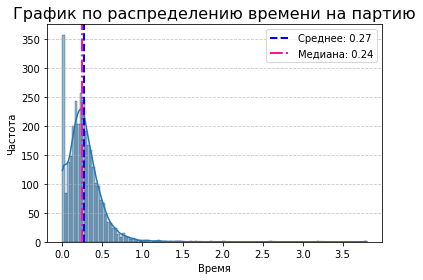

In [52]:
# Построение графика
plotting_the_normal_distribution(
    request_response,
    'measurement_time',
    'График по распределению времени на партию',
    'Время',
    'Частота',
)

In [53]:
# Основные показатели
request_response['measurement_time'].describe()

count   3,129.0000
mean        0.2680
std         0.2217
min         0.0000
25%         0.1347
50%         0.2436
75%         0.3642
max         3.8008
Name: measurement_time, dtype: float64

**<span style='color:green'>Мини вывод:</span>**

- Больше присвоеных значений в ячейках `Bulk 12`, `Bulk 14` и `Bulk 15`
- Больше пропусков в начале с `Bulk 1`
- Наблюдается не равноменрное присвоения значений или совсем отсутствия
- Почемуто время начинается с `Bulk 15` а кончается `Bulk 1`
- В строчку `3125` Время записанно равномерно
- В `4` строчке несколько раз повторяется одно итоже измерение
- `Bulk 8` не иформативна за весь перод одно значение
- В среднем измерения партии примерно 30 мин а максимум почти 4 часа
- Период измерений примерно 6 месяцев

## Задача: Анализ таблицы: <span style='color:red'>steel.data_gas</span>.

In [54]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT *
    FROM data_gas;
    '''
)
# Показываю информацию о дата фрейме
primary_information_output(request_response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   Газ 1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB
Количество пропущеных значений и их доля:


,Наименование признака,Количество пропущеных,Доля пропущеных
0,key,0,0.00%
1,Газ 1,0,0.00%


Количество полных дублированых строк в дата фрейме = 0, Доля полных дублей = 0.0%


,key,Газ 1
0,1,29.7500
1,2,12.5556
2,3,28.5548
3,4,18.8412
4,5,5.4137


### Задача: Строим график распреденление.

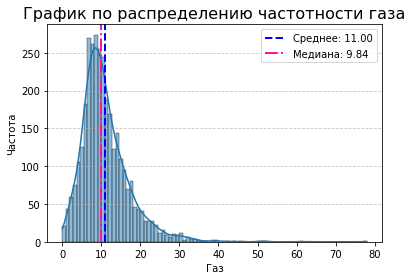

In [55]:
# Построение графика
plotting_the_normal_distribution(
    request_response,
    'Газ 1',
    'График по распределению частотности газа',
    'Газ',
    'Частота',
)

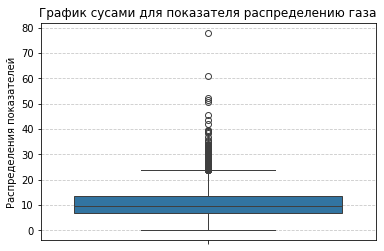

In [56]:
# Строим график
graph_with_a_mustache(
    request_response,
    'Газ 1',
    'График сусами для показателя распределению газа',
    'Распределения показателей',
)

In [57]:
# Основные показатели
request_response['Газ 1'].describe()

count   3,239.0000
mean       11.0021
std         6.2203
min         0.0084
25%         7.0431
50%         9.8363
75%        13.7699
max        77.9950
Name: Газ 1, dtype: float64

**<span style='color:green'>Мини вывод:</span>**

- Основной диапазон около с 7 по 14
- Пик сосредаточен около значения 10
- Присутствуют выбросы (Интересно иза чего получаются такие выбросы)

## Задача: Анализ таблицы: <span style='color:red'>steel.data_temp</span>.

In [58]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT *
    FROM data_temp;
    '''
)
# Показываю информацию о дата фрейме
primary_information_output(request_response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   key           18092 non-null  int64 
 1   Время замера  18092 non-null  object
 2   Температура   14665 non-null  object
dtypes: int64(1), object(2)
memory usage: 424.2+ KB
Количество пропущеных значений и их доля:


,Наименование признака,Количество пропущеных,Доля пропущеных
0,key,0,0.00%
1,Время замера,0,0.00%
2,Температура,3427,18.94%


Количество полных дублированых строк в дата фрейме = 0, Доля полных дублей = 0.0%


,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0
3,1,2019-05-03 11:18:04,1601.0
4,1,2019-05-03 11:25:59,1606.0


### Задача: Строим график распреденление.

In [59]:
# Получаем медиану температуры
median_temperature = request_response['Температура'].dropna().astype(float).median()
# Пустым значениям присваиваем медиану
request_response['Температура'] = request_response['Температура'].fillna(median_temperature)
# Изменение типа нескольких столбцов
request_response['Температура'] = request_response['Температура'].astype(float)
# Убираем значения ниже 1500 как информировал заказчик
request_response = request_response.loc[request_response['Температура'] > 1500]

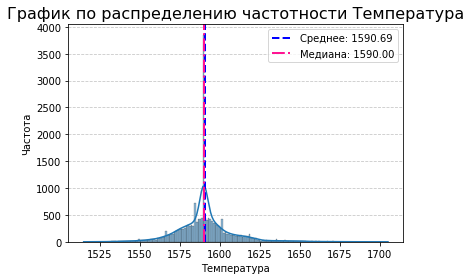

In [60]:
# Построение графика
plotting_the_normal_distribution(
    request_response,
    'Температура',
    'График по распределению частотности Температура',
    'Температура',
    'Частота',
)

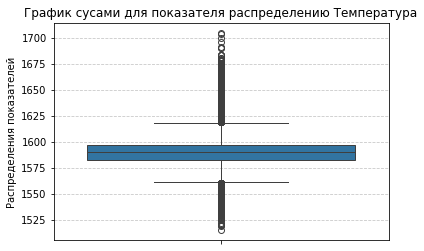

In [61]:
# Строим график
graph_with_a_mustache(
    request_response,
    'Температура',
    'График сусами для показателя распределению Температура',
    'Распределения показателей',
)

In [62]:
# Основные показатели
request_response['Температура'].describe()

count   18,087.0000
mean     1,590.6912
std         17.2376
min      1,515.0000
25%      1,583.0000
50%      1,590.0000
75%      1,597.0000
max      1,705.0000
Name: Температура, dtype: float64

**<span style='color:green'>Мини вывод:</span>**

- `18%` Присутствуют пропуски также это показывает график сусами
- Основные значения к `1600` температуре
- Нужно будет исключить значения меньше `1500`
- Жалко что нужно удалить `18%` целевого признака

## Задача: Анализ таблицы: <span style='color:red'>steel.data_wire</span>.

In [63]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT *
    FROM data_wire;
    '''
)
# Показываю информацию о дата фрейме
primary_information_output(request_response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   Wire 1  3055 non-null   float64
 2   Wire 2  1079 non-null   object 
 3   Wire 3  63 non-null     object 
 4   Wire 4  14 non-null     object 
 5   Wire 5  1 non-null      object 
 6   Wire 6  73 non-null     object 
 7   Wire 7  11 non-null     object 
 8   Wire 8  19 non-null     object 
 9   Wire 9  29 non-null     object 
dtypes: float64(1), int64(1), object(8)
memory usage: 240.8+ KB
Количество пропущеных значений и их доля:


,Наименование признака,Количество пропущеных,Доля пропущеных
0,key,0,0.00%
1,Wire 1,26,0.84%
2,Wire 2,2002,64.98%
3,Wire 3,3018,97.96%
4,Wire 4,3067,99.55%
5,Wire 5,3080,99.97%
6,Wire 6,3008,97.63%
7,Wire 7,3070,99.64%
8,Wire 8,3062,99.38%
9,Wire 9,3052,99.06%


Количество полных дублированых строк в дата фрейме = 0, Доля полных дублей = 0.0%


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.0600,None,None,None,None,None,None,None,None
1,2,96.0523,None,None,None,None,None,None,None,None
2,3,91.1602,None,None,None,None,None,None,None,None
3,4,89.0635,None,None,None,None,None,None,None,None
4,5,89.2382,9.11456,None,None,None,None,None,None,None


**<span style='color:green'>Мини вывод:</span>**

- Восновном пропуски сасредоточены с `Wire 2` - `Wire 9`
- Заполнем нулями что значит обём добавления материалов

## Задача: Анализ таблицы: <span style='color:red'>steel.data_wire_time</span>.

In [64]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    SELECT *
    FROM data_wire_time;
    '''
)
# Показываю информацию о дата фрейме
primary_information_output(request_response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   key     3081 non-null   int64 
 1   Wire 1  3055 non-null   object
 2   Wire 2  1079 non-null   object
 3   Wire 3  63 non-null     object
 4   Wire 4  14 non-null     object
 5   Wire 5  1 non-null      object
 6   Wire 6  73 non-null     object
 7   Wire 7  11 non-null     object
 8   Wire 8  19 non-null     object
 9   Wire 9  29 non-null     object
dtypes: int64(1), object(9)
memory usage: 240.8+ KB
Количество пропущеных значений и их доля:


,Наименование признака,Количество пропущеных,Доля пропущеных
0,key,0,0.00%
1,Wire 1,26,0.84%
2,Wire 2,2002,64.98%
3,Wire 3,3018,97.96%
4,Wire 4,3067,99.55%
5,Wire 5,3080,99.97%
6,Wire 6,3008,97.63%
7,Wire 7,3070,99.64%
8,Wire 8,3062,99.38%
9,Wire 9,3052,99.06%


Количество полных дублированых строк в дата фрейме = 0, Доля полных дублей = 0.0%


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:06:19,None,None,None,None,None,None,None,None
1,2,2019-05-03 11:36:50,None,None,None,None,None,None,None,None
2,3,2019-05-03 12:11:46,None,None,None,None,None,None,None,None
3,4,2019-05-03 12:43:22,None,None,None,None,None,None,None,None
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,None,None,None,None,None,None,None


In [65]:
# Выборка полей
selected_fields = request_response.columns.tolist()
selected_fields = selected_fields[1:]
# Меняем тип данных
for field in selected_fields:
    request_response[field] = pd.to_datetime(request_response[field], errors='coerce')
# Вывод info по датафрейму
request_response.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   key     3081 non-null   int64         
 1   Wire 1  3055 non-null   datetime64[ns]
 2   Wire 2  1079 non-null   datetime64[ns]
 3   Wire 3  63 non-null     datetime64[ns]
 4   Wire 4  14 non-null     datetime64[ns]
 5   Wire 5  1 non-null      datetime64[ns]
 6   Wire 6  73 non-null     datetime64[ns]
 7   Wire 7  11 non-null     datetime64[ns]
 8   Wire 8  19 non-null     datetime64[ns]
 9   Wire 9  29 non-null     datetime64[ns]
dtypes: datetime64[ns](9), int64(1)
memory usage: 240.8 KB


### Задача: Ищем максимальное и минемальное время снятия подачи сыпучих материалов.

In [66]:
# Получим минимум по строкам из по колонкам
request_response['min_time'] = request_response[selected_fields].min(axis='columns')
# Получим максимум по строкам
request_response['max_time'] = request_response[selected_fields].max(axis='columns')
# Вычисляем разницу и переводим в часы
request_response['measurement_time'] = (request_response['max_time'] - request_response['min_time']) / pd.Timedelta(hours=1)
# Вывод результата
request_response.head()

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9,min_time,max_time,measurement_time
0,1,2019-05-03 11:06:19,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:06:19,2019-05-03 11:06:19,0.0000
1,2,2019-05-03 11:36:50,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:36:50,2019-05-03 11:36:50,0.0000
2,3,2019-05-03 12:11:46,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:11:46,2019-05-03 12:11:46,0.0000
3,4,2019-05-03 12:43:22,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:43:22,2019-05-03 12:43:22,0.0000
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 13:15:34,2019-05-03 13:20:44,0.0861


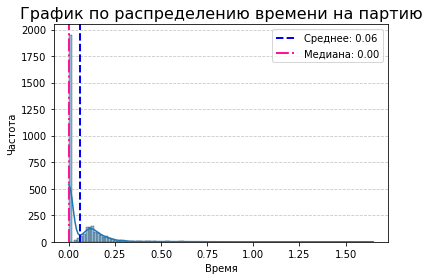

In [67]:
# Построение графика
plotting_the_normal_distribution(
    request_response,
    'measurement_time',
    'График по распределению времени на партию',
    'Время',
    'Частота',
)

In [68]:
# Основные показатели
request_response['measurement_time'].describe()

count   3,081.0000
mean        0.0596
std         0.1100
min         0.0000
25%         0.0000
50%         0.0000
75%         0.1114
max         1.6492
Name: measurement_time, dtype: float64

**<span style='color:green'>Мини вывод:</span>**

- Заполнения восновном в первых 2 калонках
- Подача метериала не превышает 2 часов
- Восновном измерения в одной партии еденичные и этого достаточно

# <span style='color:Blue'>Шаг. Объедините таблицы по ключу</span>

## Задача: Получаем полную выгруску.

In [69]:
# Запрос SQL
request_response = completing_requests_sql(
    '''
    WITH
        -- ### Обработка таблицы data_temp ###
        --(Выбираем те партии где есть значение в последнем измерении)
        dtg AS (
            SELECT
                key,
                "Время замера" AS "mesaure_time",
                "Температура" AS "temperature"
            FROM data_temp
            WHERE key NOT IN (
                SELECT key
                FROM (
                    SELECT 
                        key,
                        "Температура",
                        ROW_NUMBER() OVER (PARTITION BY key ORDER BY "Время замера" DESC) AS rn
                    FROM data_temp
                )
                WHERE rn = 1 AND "Температура" IS NULL
            )        
        ),
        
        --(Выбираю температуру на стартовой позиции)
        dtg_min AS (
            SELECT
                key,
                temperature AS start_temperature
            FROM (
                SELECT *,
                       ROW_NUMBER() OVER (PARTITION BY key ORDER BY "mesaure_time") AS rn
                FROM dtg
            ) AS bd
            WHERE rn = 1
        ),
        
        --(Выбираю температуру на последнем измерении что и является целевым признаком)
        dtg_max AS (
            SELECT
                key,
                temperature
            FROM (
                SELECT *,
                       ROW_NUMBER() OVER (PARTITION BY key ORDER BY "mesaure_time" DESC) AS rn
                FROM dtg
            ) AS bd
            WHERE rn = 1
        ),
        
        --(Обединяю в одну таблицу по температуре тоесть dtg_min и dtg_max)
        dt AS (
            SELECT
                dtg_min.key,
                start_temperature,
                temperature
            FROM dtg_min
            LEFT JOIN dtg_max ON dtg_min.key = dtg_max.key
        ),

        -- ### Обработка таблицы data_arc ###
        --(Собираю для каждой партии количество измерений)
        nl AS (
            SELECT 
                key, COUNT(*) AS "number_launches"
            FROM data_arc
            GROUP BY key
        ),
        
        --(Создаю новые признаки с обединения с последним признаком согласно иследованию)
        da_preparation AS (
            SELECT 
                *,
                (julianday(datetime("Конец нагрева дугой")) - julianday(datetime("Начало нагрева дугой"))) * 86400 AS "heating_duration",
                "Активная мощность" + "Реактивная мощность" AS "total_capacity",
                "Активная мощность" / "Реактивная мощность" AS "power_ratio"
            FROM data_arc AS da
            LEFT JOIN nl ON da.key = nl.key
        ),
        
        --(Выбираю по времени последние награва дугой)
        da AS (
            SELECT
                key,
                number_launches,
                heating_duration,
                total_capacity,
                power_ratio
            FROM (
                SELECT *,
                       ROW_NUMBER() OVER (PARTITION BY key ORDER BY "Конец нагрева дугой" DESC) AS rn
                FROM da_preparation
            ) AS bd
            WHERE rn = 1
        ),
        
        -- ### Обединения dt и da ###
        dta AS (
            SELECT
                dt.key,
                number_launches,
                heating_duration,
                total_capacity,
                power_ratio,
                start_temperature,
                temperature
            FROM dt
            INNER JOIN da ON dt.key = da.key
        ),

        -- ### Подготовка таблицы data_bulk ###
        db AS (
            SELECT
                key,
                COALESCE("Bulk 1", 0) AS bulk_1,
                COALESCE("Bulk 2", 0) AS bulk_2,
                COALESCE("Bulk 3", 0) AS bulk_3,
                COALESCE("Bulk 4", 0) AS bulk_4,
                COALESCE("Bulk 5", 0) AS bulk_5,
                COALESCE("Bulk 6", 0) AS bulk_6,
                COALESCE("Bulk 7", 0) AS bulk_7,
                COALESCE("Bulk 8", 0) AS bulk_8,
                COALESCE("Bulk 9", 0) AS bulk_9,
                COALESCE("Bulk 10", 0) AS bulk_10,
                COALESCE("Bulk 11", 0) AS bulk_11,
                COALESCE("Bulk 12", 0) AS bulk_12,
                COALESCE("Bulk 13", 0) AS bulk_13,
                COALESCE("Bulk 14", 0) AS bulk_14,
                COALESCE("Bulk 15", 0) AS bulk_15
            FROM data_bulk
        ),

        -- ### Подготовка таблицы data_gas ###
        dg AS (
            SELECT
                key,
                "Газ 1" AS gas
            FROM data_gas
        ),

        -- ### Подготовка таблицы data_wire ###
        dw AS (
            SELECT
                key,
                COALESCE("Wire 1", 0) AS wire_1,
                COALESCE("Wire 2", 0) AS wire_2,
                COALESCE("Wire 3", 0) AS wire_3,
                COALESCE("Wire 4", 0) AS wire_4,
                COALESCE("Wire 5", 0) AS wire_5,
                COALESCE("Wire 6", 0) AS wire_6,
                COALESCE("Wire 7", 0) AS wire_7,
                COALESCE("Wire 8", 0) AS wire_8,
                COALESCE("Wire 9", 0) AS wire_9
            FROM data_wire
        )

    SELECT
        dta.key,
        number_launches,
        heating_duration,
        total_capacity,
        power_ratio,
        start_temperature,
        temperature,
        bulk_1,
        bulk_2,
        bulk_3,
        bulk_4,
        bulk_5,
        bulk_6,
        bulk_7,
        bulk_8,
        bulk_9,
        bulk_10,
        bulk_11,
        bulk_12,
        bulk_13,
        bulk_14,
        bulk_15,
        gas,
        wire_1,
        wire_2,
        wire_3,
        wire_4,
        wire_5,
        wire_6,
        wire_7,
        wire_8,
        wire_9
    FROM dta
    LEFT JOIN db ON dta.key = db.key
    LEFT JOIN dg ON dta.key = dg.key
    LEFT JOIN dw ON dta.key = dw.key
    WHERE 
        wire_9 IS NOT NULL AND 
        bulk_15 IS NOT NULL AND
        gas IS NOT NULL;
    '''
)
# Показываю информацию о дата фрейме
primary_information_output(request_response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2329 entries, 0 to 2328
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                2329 non-null   int64  
 1   number_launches    2329 non-null   int64  
 2   heating_duration   2329 non-null   float64
 3   total_capacity     2329 non-null   float64
 4   power_ratio        2329 non-null   float64
 5   start_temperature  2329 non-null   object 
 6   temperature        2329 non-null   object 
 7   bulk_1             2329 non-null   float64
 8   bulk_2             2329 non-null   float64
 9   bulk_3             2329 non-null   float64
 10  bulk_4             2329 non-null   float64
 11  bulk_5             2329 non-null   object 
 12  bulk_6             2329 non-null   object 
 13  bulk_7             2329 non-null   object 
 14  bulk_8             2329 non-null   object 
 15  bulk_9             2329 non-null   object 
 16  bulk_10            2329 

,Наименование признака,Количество пропущеных,Доля пропущеных
0,key,0,0.00%
1,number_launches,0,0.00%
2,heating_duration,0,0.00%
3,total_capacity,0,0.00%
4,power_ratio,0,0.00%
5,start_temperature,0,0.00%
6,temperature,0,0.00%
7,bulk_1,0,0.00%
8,bulk_2,0,0.00%
9,bulk_3,0,0.00%


Количество полных дублированых строк в дата фрейме = 0, Доля полных дублей = 0.0%


,key,number_launches,heating_duration,total_capacity,power_ratio,start_temperature,temperature,bulk_1,bulk_2,bulk_3,...,gas,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9
0,1,5,148.0000,1.5108,1.3471,1571.0,1613.0,0.0000,0.0000,0.0000,...,29.7500,60.0600,0,0,0,0,0,0,0,0
1,2,4,210.0000,1.3288,1.4494,1581.0,1602.0,0.0000,0.0000,0.0000,...,12.5556,96.0523,0,0,0,0,0,0,0,0
2,3,5,65.0000,0.6943,1.5471,1596.0,1599.0,0.0000,0.0000,0.0000,...,28.5548,91.1602,0,0,0,0,0,0,0,0
3,4,4,278.0000,1.5197,1.3213,1601.0,1625.0,0.0000,0.0000,0.0000,...,18.8412,89.0635,0,0,0,0,0,0,0,0
4,5,4,71.0000,1.5538,1.3513,1576.0,1602.0,0.0000,0.0000,0.0000,...,5.4137,89.2382,9.11456,0,0,0,0,0,0,0


In [70]:
# Выборка полей
list_columns = [
    'start_temperature',
    'temperature',
    'bulk_5',
    'bulk_6',
    'bulk_7',
    'bulk_8',
    'bulk_9',
    'bulk_10',
    'bulk_11',
    'bulk_12',
    'bulk_13',
    'bulk_14',
    'bulk_15',
    'wire_2',
    'wire_3',
    'wire_4',
    'wire_5',
    'wire_6',
    'wire_7',
    'wire_8',
    'wire_9',
]
# Меняю тип данных на float
for field in list_columns: 
    request_response[field] = request_response[field].astype(float)

In [71]:
# Показываю информацию о дата фрейме
primary_information_output(request_response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2329 entries, 0 to 2328
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                2329 non-null   int64  
 1   number_launches    2329 non-null   int64  
 2   heating_duration   2329 non-null   float64
 3   total_capacity     2329 non-null   float64
 4   power_ratio        2329 non-null   float64
 5   start_temperature  2329 non-null   float64
 6   temperature        2329 non-null   float64
 7   bulk_1             2329 non-null   float64
 8   bulk_2             2329 non-null   float64
 9   bulk_3             2329 non-null   float64
 10  bulk_4             2329 non-null   float64
 11  bulk_5             2329 non-null   float64
 12  bulk_6             2329 non-null   float64
 13  bulk_7             2329 non-null   float64
 14  bulk_8             2329 non-null   float64
 15  bulk_9             2329 non-null   float64
 16  bulk_10            2329 

,Наименование признака,Количество пропущеных,Доля пропущеных
0,key,0,0.00%
1,number_launches,0,0.00%
2,heating_duration,0,0.00%
3,total_capacity,0,0.00%
4,power_ratio,0,0.00%
5,start_temperature,0,0.00%
6,temperature,0,0.00%
7,bulk_1,0,0.00%
8,bulk_2,0,0.00%
9,bulk_3,0,0.00%


Количество полных дублированых строк в дата фрейме = 0, Доля полных дублей = 0.0%


,key,number_launches,heating_duration,total_capacity,power_ratio,start_temperature,temperature,bulk_1,bulk_2,bulk_3,...,gas,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9
0,1,5,148.0000,1.5108,1.3471,"1,571.0000","1,613.0000",0.0000,0.0000,0.0000,...,29.7500,60.0600,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,2,4,210.0000,1.3288,1.4494,"1,581.0000","1,602.0000",0.0000,0.0000,0.0000,...,12.5556,96.0523,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,3,5,65.0000,0.6943,1.5471,"1,596.0000","1,599.0000",0.0000,0.0000,0.0000,...,28.5548,91.1602,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,4,4,278.0000,1.5197,1.3213,"1,601.0000","1,625.0000",0.0000,0.0000,0.0000,...,18.8412,89.0635,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,5,4,71.0000,1.5538,1.3513,"1,576.0000","1,602.0000",0.0000,0.0000,0.0000,...,5.4137,89.2382,9.1146,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


**<span style='color:green'>Мини вывод:</span>**

- Таблица готова
- Наименование полей +
- Пропуски +
- Полные дубли +
- Тип данных +

## Проведения исследовательскова анализа итогового запроса.

### Задача: Посмотрим DESCRIBE.

In [72]:
# Выполнения команды
request_response.describe().T

,count,mean,std,min,25%,50%,75%,max
key,"2,329.0000","1,251.8325",714.7624,1.0000,630.0000,"1,255.0000","1,868.0000","2,499.0000"
number_launches,"2,329.0000",4.6956,1.6066,1.0000,4.0000,5.0000,6.0000,16.0000
heating_duration,"2,329.0000",117.9167,62.8125,11.0000,72.0000,103.0000,147.0000,555.0000
total_capacity,"2,329.0000",1.1442,0.4479,0.3826,0.7978,1.0358,1.4254,2.5143
power_ratio,"2,329.0000",1.3714,0.1325,1.0196,1.2772,1.3774,1.4700,1.7682
start_temperature,"2,329.0000","1,586.7188",28.2908,"1,191.0000","1,571.0000","1,587.0000","1,603.0000","1,660.0000"
temperature,"2,329.0000","1,593.3654",11.2009,"1,541.0000","1,587.0000","1,593.0000","1,598.0000","1,653.0000"
bulk_1,"2,329.0000",3.4277,12.4121,0.0000,0.0000,0.0000,0.0000,185.0000
bulk_2,"2,329.0000",1.4225,19.0821,0.0000,0.0000,0.0000,0.0000,325.0000
bulk_3,"2,329.0000",47.3482,75.3104,0.0000,0.0000,0.0000,80.0000,454.0000


### Задача: Поле [number_launches] с целевым признаком.

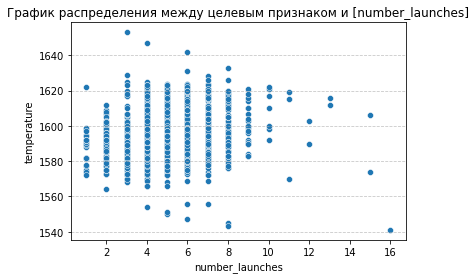

In [73]:
# Строю график
sns.scatterplot(data=request_response, x="number_launches", y="temperature")
plt.title('График распределения между целевым признаком и [number_launches]')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show();

**<span style='color:green'>Мини вывод:</span>**

- Значений сосредаточино по `number_launches` в диапазоне от `2` до `9`
- Целевой признак `temperature` в диапазоне от `1560` по `1625`
- Немного похоже на овал у которого еть направления

### Задача: Поле [heating_duration] с целевым признаком.

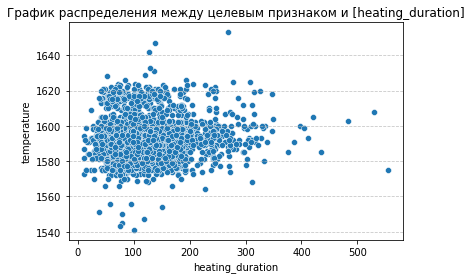

In [74]:
# Строю график
sns.scatterplot(data=request_response, x="heating_duration", y="temperature")
plt.title('График распределения между целевым признаком и [heating_duration]')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show();

**<span style='color:green'>Мини вывод:</span>**

- Значений сосредаточино по `heating_duration` в диапазоне от `10` до `200`
- Целевой признак `temperature` в диапазоне от `1565` по `1625`
- Похоже нечто круглое с хвостиком при увеличении `heating_duration` 

### Задача: Поле [total_capacity] с целевым признаком.

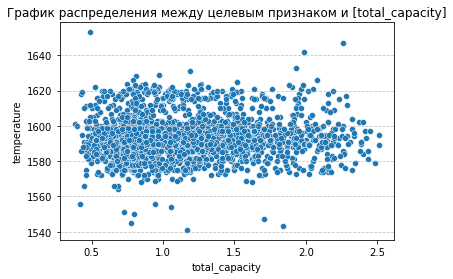

In [75]:
# Строю график
sns.scatterplot(data=request_response, x="total_capacity", y="temperature")
plt.title('График распределения между целевым признаком и [total_capacity]')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show();

**<span style='color:green'>Мини вывод:</span>**

- Значений сосредаточино по все длине `total_capacity`
- Целевой признак `temperature` в диапазоне от `1560` по `1625`
- Похоже удлинёный овал

### Задача: Поле [power_ratio] с целевым признаком.

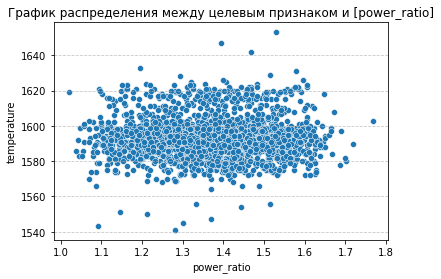

In [76]:
# Строю график
sns.scatterplot(data=request_response, x="power_ratio", y="temperature")
plt.title('График распределения между целевым признаком и [power_ratio]')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show();

**<span style='color:green'>Мини вывод:</span>**

- Значений сосредаточино по все длине `power_ratio` с `1.1` по `1.7`
- Целевой признак `temperature` в диапазоне от `1570` по `1625`
- Похоже удлинёный овал

### Задача: Поле [start_temperature] с целевым признаком.

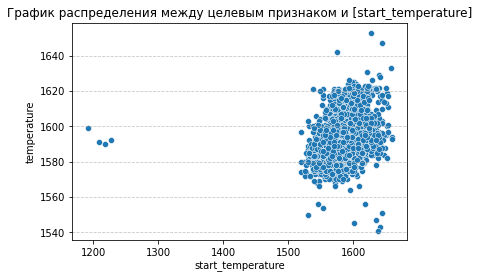

In [77]:
# Строю график
sns.scatterplot(data=request_response, x="start_temperature", y="temperature")
plt.title('График распределения между целевым признаком и [start_temperature]')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show();

In [78]:
# Убрать лишние значения
request_response = request_response.loc[request_response['start_temperature'] > 1500]

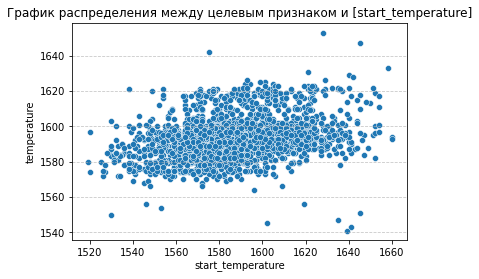

In [79]:
# Строю график
sns.scatterplot(data=request_response, x="start_temperature", y="temperature")
plt.title('График распределения между целевым признаком и [start_temperature]')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show();

**<span style='color:green'>Мини вывод:</span>**

- Значений сосредаточино по все длине `start_temperature` с `1530` по `1650`
- Целевой признак `temperature` в диапазоне от `1570` по `1620`
- Похож на сильно приплюснутый овал

### Задача: Поле [gas] с целевым признаком.

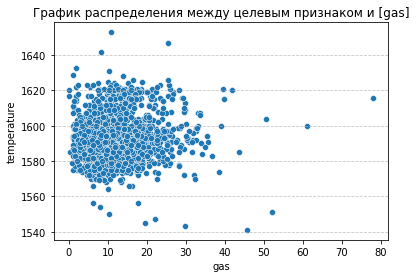

In [80]:
# Строю график
sns.scatterplot(data=request_response, x="gas", y="temperature")
plt.title('График распределения между целевым признаком и [gas]')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show();

**<span style='color:green'>Мини вывод:</span>**

- Значений сосредаточино по все длине `start_temperature` с `3` по `30`
- Целевой признак `temperature` в диапазоне от `1570` по `1625`
- Похоже на круг без направления

### Задача: Поле [bulk 1 - 15] с целевым признаком.

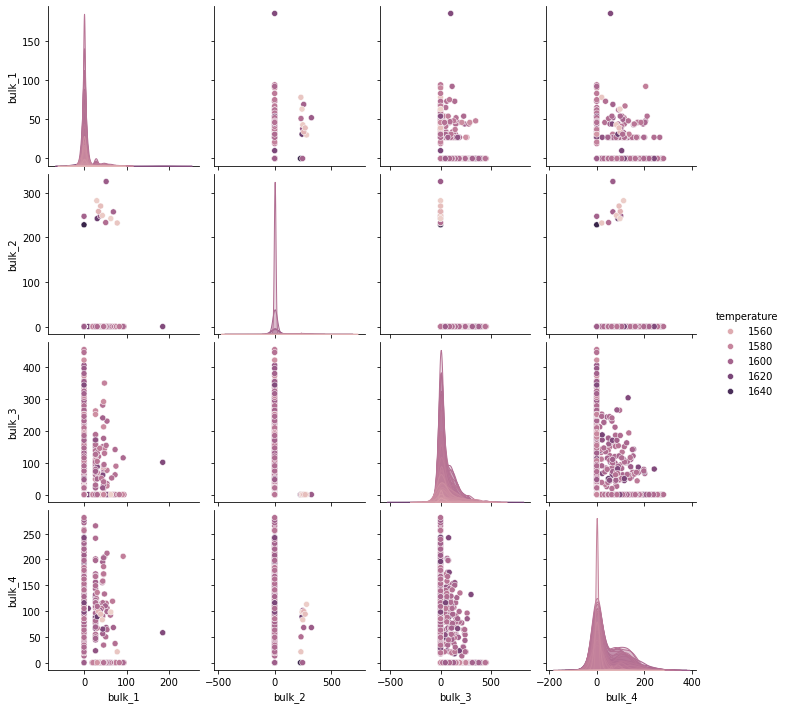

In [81]:
# Строю график
list_field = [f'bulk_{x}' for x in range(1, 5)]
list_field.append('temperature')
sns.pairplot(
    request_response[list_field],
    hue='temperature',
    #corner=True,
);

**<span style='color:green'>Мини вывод:</span>**

- Очень много на нуливых значениях (Сказываются не заполненые данные)
- Если данные есть они образуют треугольник, Основание начинается от `0`
- Больше данных восновном от `1560` до `1620`
- Также присутствуют маленькие группы данных
- Напрашивается что если 

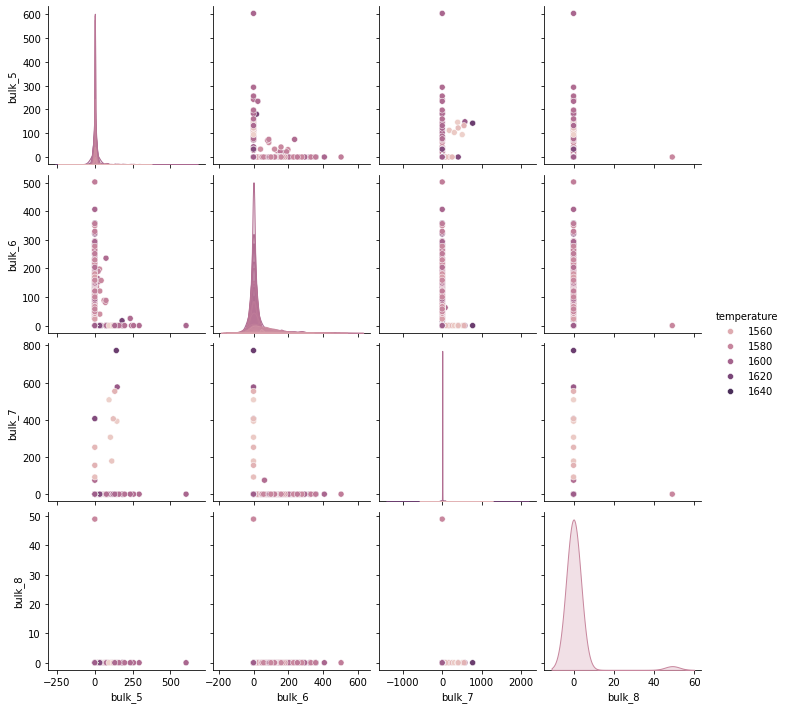

In [82]:
# Строю график
list_field = [f'bulk_{x}' for x in range(5, 9)]
list_field.append('temperature')
sns.pairplot(
    request_response[list_field],
    hue='temperature',
    #corner=True,
);

**<span style='color:green'>Мини вывод:</span>**

- Очень мало показателей что видно на графиках
- Больше данных восновном от 1560 до 1620
- Ноль являестя преобладающим показателям

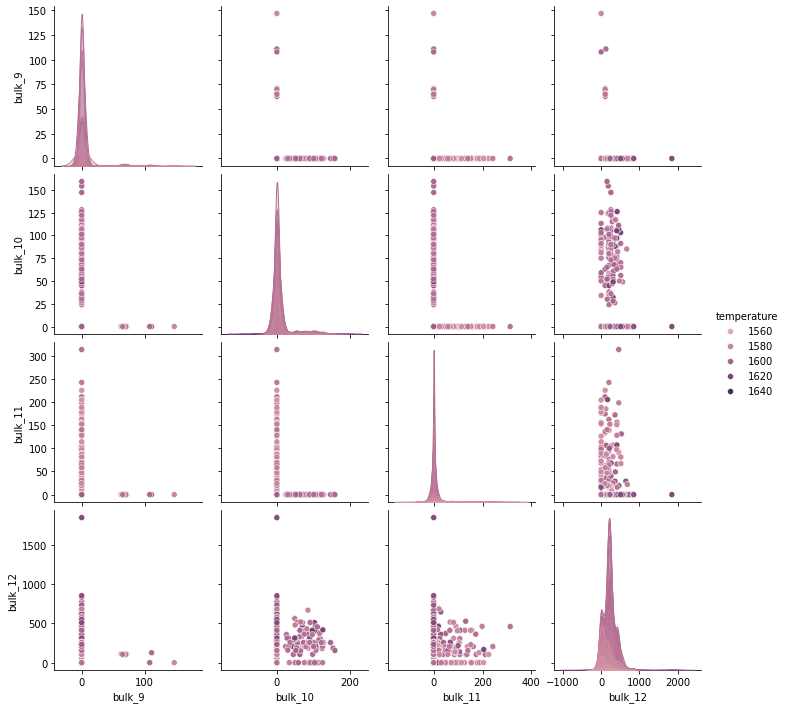

In [83]:
# Строю график
list_field = [f'bulk_{x}' for x in range(9, 13)]
list_field.append('temperature')
sns.pairplot(
    request_response[list_field],
    hue='temperature',
    #corner=True,
);

**<span style='color:green'>Мини вывод:</span>**

- Больше данных восновном от 1560 до 1620
- Большинство данные формируются около нуля
- Видемо где большинство есть нули связи совсем слабая
- Только `bulk_10` и `bulk_11` образуют нечто похожие на толи круг толи удлинёный приплюснотый овал

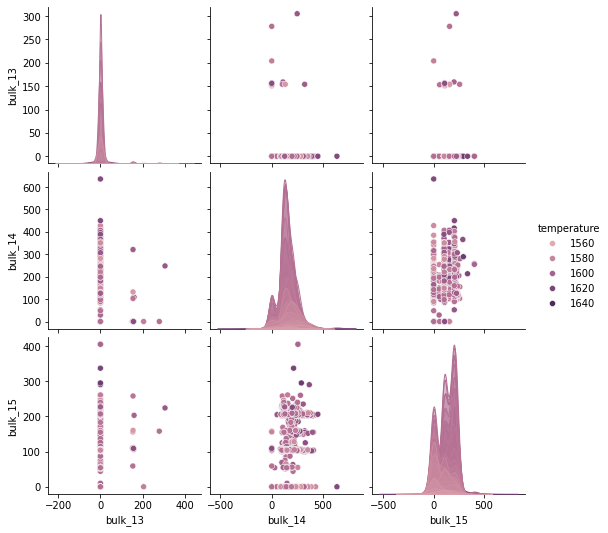

In [84]:
# Строю график
list_field = [f'bulk_{x}' for x in range(13, 16)]
list_field.append('temperature')
sns.pairplot(
    request_response[list_field],
    hue='temperature',
    #corner=True,
);

**<span style='color:green'>Мини вывод:</span>**

- Больше данных восновном от 1560 до 1620
- Взаимосвязь наблюдается bulk_14 и bulk_15 образуют нечто похожие на удлинёный приплюснотый овал
- Большо формиравагние нуливое

### Задача: Поле [wire 1 - 9] с целевым признаком.

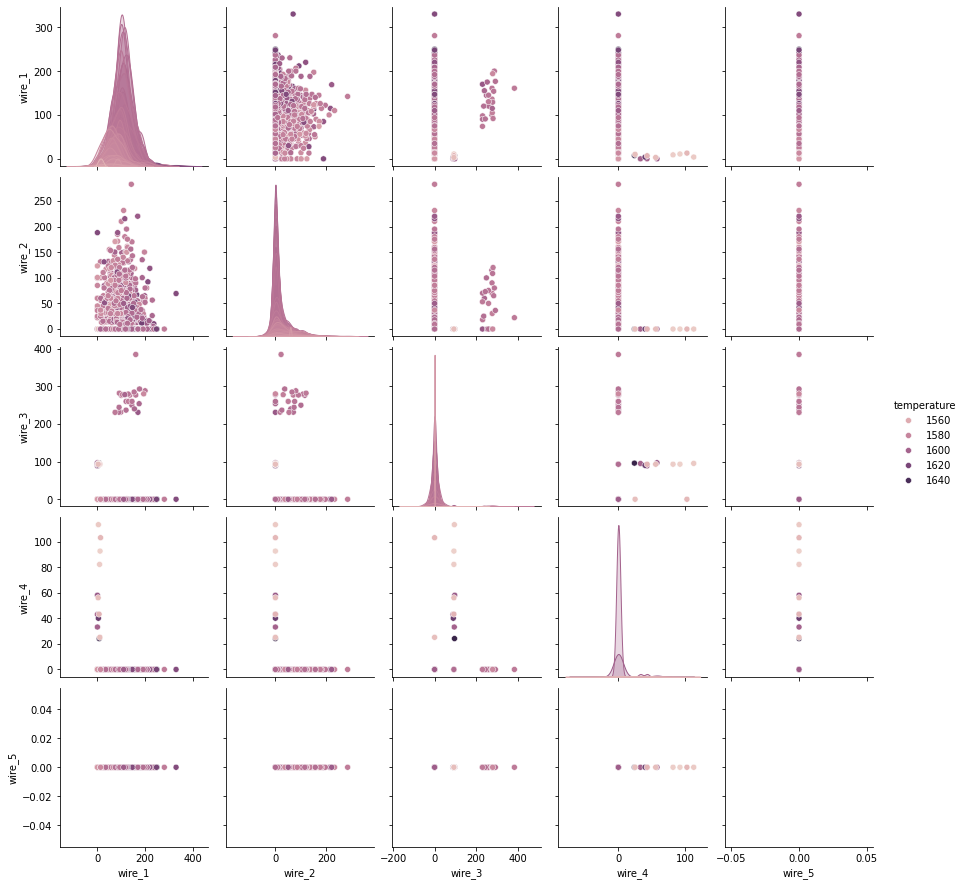

In [85]:
# Строю график
list_field = [f'wire_{x}' for x in range(1, 6)]
list_field.append('temperature')
sns.pairplot(
    request_response[list_field],
    hue='temperature',
    #corner=True,
);

**<span style='color:green'>Мини вывод:</span>**

- Больше данных восновном от 1560 до 1620
- Только первые 3 столбца есть взаимосязь(Это и понятно данных больше было там)
- Остальное формируется по нулям

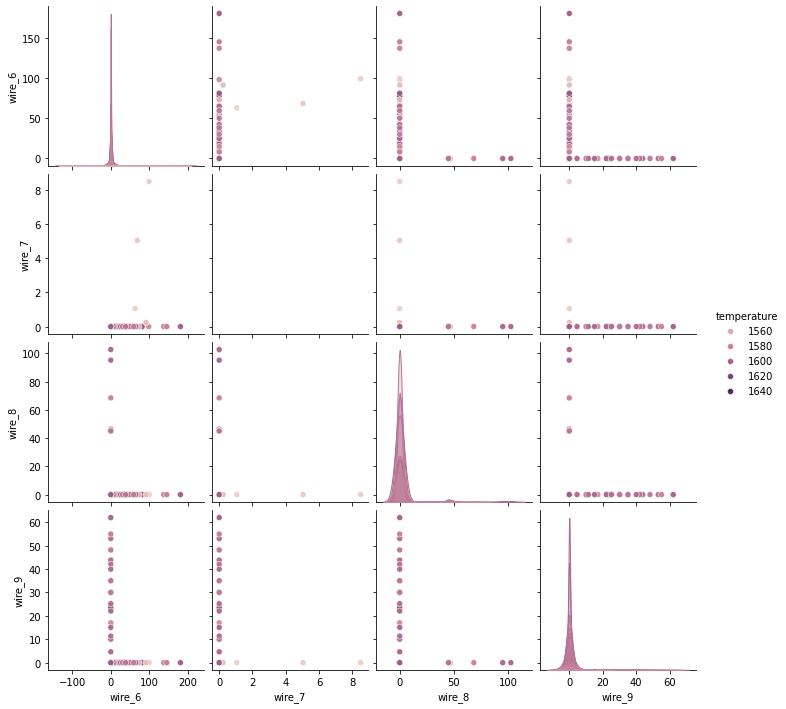

In [86]:
# Строю график
list_field = [f'wire_{x}' for x in range(6, 10)]
list_field.append('temperature')
sns.pairplot(
    request_response[list_field],
    hue='temperature',
    #corner=True,
);

**<span style='color:green'>Мини вывод:</span>**

- Формирование восновном нуливое (В последних колонках меньше всего было данных)
- Больше данных восновном от 1560 до 1600

## Проведения корреляционного анализа.

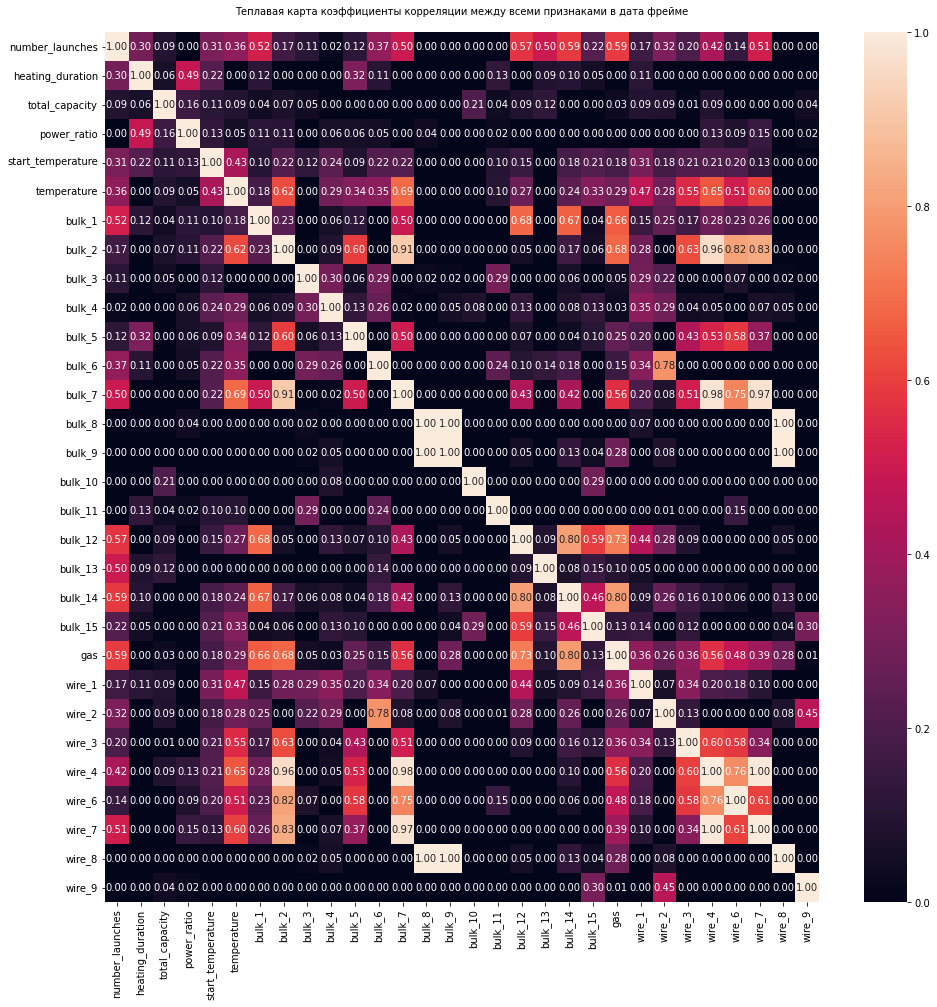

In [87]:
# Перечислим не актуальные признаки для построения
list_non_participating_features = [
    'key',
]
# Строим тепловую карту
heat_map_output(
    request_response.drop(list_non_participating_features, axis=1),
    #presentation_columns
);

**<span style='color:green'>Мини вывод:</span>**

- Будем считать что если кореляция выше или равно 0.9 то мультиколлинеарность присутствует и сетими признаками стоит поработать.
- Да мультиколлинеарность присутствует но между `bulk_8 - 9` и `wire_8`
- Есть признаки которые совсем не имеют связки только лиш частично
- Новые признаки 3 из 5 не показывает сильные результат взаимосвязи с целевым но есть
- Если таблицы будет мало для нужного результата стоит задуматься над новыми признаками

# <span style='color:Blue'>Шаг. Подготовьте данные к обучению модели</span>

## Задача: Выбираем признаки.

In [88]:
# Выбираем признаки
selected_features = [
    'number_launches',
    'heating_duration',
    'total_capacity',
    'power_ratio',
    'start_temperature',
    'temperature',
    'bulk_1',
    'bulk_2',
    'bulk_3',
    'bulk_4',
    'bulk_5',
    'bulk_6',
    'bulk_7',
    #'bulk_8',
    #'bulk_9',
    'bulk_10',
    'bulk_11',
    'bulk_12',
    'bulk_13',
    'bulk_14',
    'bulk_15',
    'gas',
    'wire_1',
    'wire_2',
    'wire_3',
    'wire_4',
    'wire_5',
    'wire_6',
    'wire_7',
    #'wire_8',
    'wire_9',
]
# Присваиваем выбраный диапазон
request_response = request_response[selected_features]

In [89]:
# Показ дата фрейма
request_response

,number_launches,heating_duration,total_capacity,power_ratio,start_temperature,temperature,bulk_1,bulk_2,bulk_3,bulk_4,...,bulk_15,gas,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_9
0,5,148.0000,1.5108,1.3471,"1,571.0000","1,613.0000",0.0000,0.0000,0.0000,43.0000,...,154.0000,29.7500,60.0600,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,4,210.0000,1.3288,1.4494,"1,581.0000","1,602.0000",0.0000,0.0000,0.0000,73.0000,...,154.0000,12.5556,96.0523,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,5,65.0000,0.6943,1.5471,"1,596.0000","1,599.0000",0.0000,0.0000,0.0000,34.0000,...,153.0000,28.5548,91.1602,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,4,278.0000,1.5197,1.3213,"1,601.0000","1,625.0000",0.0000,0.0000,0.0000,81.0000,...,154.0000,18.8412,89.0635,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,4,71.0000,1.5538,1.3513,"1,576.0000","1,602.0000",0.0000,0.0000,0.0000,78.0000,...,152.0000,5.4137,89.2382,9.1146,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2324,4,99.0000,1.5239,1.3026,"1,570.0000","1,591.0000",0.0000,0.0000,21.0000,0.0000,...,223.0000,7.1257,89.1509,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2325,6,228.0000,2.1335,1.5890,"1,554.0000","1,591.0000",0.0000,0.0000,0.0000,63.0000,...,226.0000,9.4126,114.1795,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2326,3,206.0000,2.1774,1.4011,"1,571.0000","1,589.0000",0.0000,0.0000,0.0000,85.0000,...,226.0000,6.2717,94.0867,9.0480,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2327,5,41.0000,0.8727,1.3981,"1,591.0000","1,594.0000",0.0000,0.0000,90.0000,0.0000,...,207.0000,14.9537,118.1107,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


## Задача: Подготовка train и test выборку.

In [90]:
# Делим данные на тренировачные и тестовые
X_train, X_test, y_train, y_test = train_test_split(
    request_response.drop([target_attribute], axis=1),
    request_response[target_attribute],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    #stratify=request_response[target_attribute],
)

In [91]:
# Конвертация типов
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

# Преобразуем X_train и X_test
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

# <span style='color:Blue'>Шаг. Обучение лучшей модели</span>

## Задача: Поодготовка к сбору результатов.

In [92]:
# Инициализация класс для показы рейтингов
rating_table = RatingBestModels(X_train, X_test, y_train, y_test)

## Задача: Обучение CatBoostRegressor.

In [93]:
# Инициализация модели
model = CatBoostRegressor(
    random_state=RANDOM_STATE,
    verbose=0
    # cat_features=cat_columns  # если есть категориальные признаки
)

# Подготовка гиперпараметров
param = {
    'n_estimators': optuna.distributions.IntDistribution(50, 300),
    'learning_rate': optuna.distributions.FloatDistribution(0.01, 0.3, log=True),
    'depth': optuna.distributions.IntDistribution(4, 10),
    'l2_leaf_reg': optuna.distributions.FloatDistribution(1, 10),
    'bagging_temperature': optuna.distributions.FloatDistribution(0, 1),
    'random_strength': optuna.distributions.FloatDistribution(0, 1),
    'grow_policy': optuna.distributions.CategoricalDistribution(['SymmetricTree', 'Depthwise', 'Lossguide'])
}

# Производим поиск по оптимальным вариантам лучшей модели
cbr_best_model = OptunaSearchCV(
    model,
    param,
    cv=5,
    n_trials=70,
    scoring=METRIC,
    random_state=RANDOM_STATE,
    timeout=600
)

# Запускаем обучение 
cbr_best_model.fit(X_train, y_train)

OptunaSearchCV(cv=5,
               estimator=<catboost.core.CatBoostRegressor object at 0x7f85761d2eb0>,
               n_jobs=1, n_trials=70,
               param_distributions={'bagging_temperature': FloatDistribution(high=1.0, log=False, low=0.0, step=None),
                                    'depth': IntDistribution(high=10, log=False, low=4, step=1),
                                    'grow_policy': CategoricalDistribution(choices=('SymmetricTree', 'Depthwise', 'Lossguide')),
                                    'l2_leaf_reg': FloatDistribution(high=10.0, log=False, low=1.0, step=None),
                                    'learning_rate': FloatDistribution(high=0.3, log=True, low=0.01, step=None),
                                    'n_estimators': IntDistribution(high=300, log=False, low=50, step=1),
                                    'random_strength': FloatDistribution(high=1.0, log=False, low=0.0, step=None)},
               random_state=270426, scoring='neg_mean_absolute_error',
               timeout=600)

In [94]:
# Записываю результат
rating_table.load(
    cbr_best_model,
    'CatBoostRegressor',
)

## Задача: Обучение DecisionTreeRegressor.

In [95]:
# Инициализация модели
model = DecisionTreeRegressor(
    random_state=RANDOM_STATE
)

# Подготовка гиперпараметров
param = {
    'max_depth': optuna.distributions.IntDistribution(3, 20),
    'min_samples_split': optuna.distributions.IntDistribution(2, 20),
    'min_samples_leaf': optuna.distributions.IntDistribution(1, 10),
    'max_features': optuna.distributions.CategoricalDistribution(['sqrt', 'log2', None]),
    'criterion': optuna.distributions.CategoricalDistribution(['squared_error', 'friedman_mse', 'absolute_error']),
    'splitter': optuna.distributions.CategoricalDistribution(['best', 'random'])
}

# Производим поиск по оптимальным вариантам лучшей модели
dtr_best_model = OptunaSearchCV(
    model,
    param,
    cv=5,
    n_trials=70,
    scoring=METRIC,
    random_state=RANDOM_STATE,
    timeout=300,
)

# Запускаем обучение 
dtr_best_model.fit(X_train, y_train)

OptunaSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=270426),
               n_jobs=1, n_trials=70,
               param_distributions={'criterion': CategoricalDistribution(choices=('squared_error', 'friedman_mse', 'absolute_error')),
                                    'max_depth': IntDistribution(high=20, log=False, low=3, step=1),
                                    'max_features': CategoricalDistribution(choices=('sqrt', 'log2', None)),
                                    'min_samples_leaf': IntDistribution(high=10, log=False, low=1, step=1),
                                    'min_samples_split': IntDistribution(high=20, log=False, low=2, step=1),
                                    'splitter': CategoricalDistribution(choices=('best', 'random'))},
               random_state=270426, scoring='neg_mean_absolute_error',
               timeout=300)

In [96]:
# Записываю результат
rating_table.load(
    dtr_best_model,
    'DecisionTreeRegressor',
)

## Задача: Обучение RandomForestRegressor.

In [97]:
# Инициализация модели
model = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Подготовка гиперпараметров
param = {
    'n_estimators': optuna.distributions.IntDistribution(50, 300),
    'max_depth': optuna.distributions.IntDistribution(3, 20),
    'min_samples_split': optuna.distributions.IntDistribution(2, 20),
    'min_samples_leaf': optuna.distributions.IntDistribution(1, 10),
    'max_features': optuna.distributions.CategoricalDistribution(['sqrt', 'log2', None]),
    'bootstrap': optuna.distributions.CategoricalDistribution([True, False]),
    'criterion': optuna.distributions.CategoricalDistribution(['squared_error', 'absolute_error']),
    'max_samples': optuna.distributions.FloatDistribution(0.5, 1.0)
}

# Производим поиск по оптимальным вариантам лучшей модели
rfr_best_model = OptunaSearchCV(
    model,
    param,
    cv=5,
    n_trials=70,
    scoring=METRIC,
    random_state=RANDOM_STATE,
    timeout=600,
)

# Запускаем обучение 
rfr_best_model.fit(X_train, y_train)

OptunaSearchCV(cv=5,
               estimator=RandomForestRegressor(n_jobs=-1, random_state=270426),
               n_jobs=1, n_trials=70,
               param_distributions={'bootstrap': CategoricalDistribution(choices=(True, False)),
                                    'criterion': CategoricalDistribution(choices=('squared_error', 'absolute_error')),
                                    'max_depth': IntDistribution(high=20, log=False, low=3, step=1),
                                    'max_features': CategoricalD...log2', None)),
                                    'max_samples': FloatDistribution(high=1.0, log=False, low=0.5, step=None),
                                    'min_samples_leaf': IntDistribution(high=10, log=False, low=1, step=1),
                                    'min_samples_split': IntDistribution(high=20, log=False, low=2, step=1),
                                    'n_estimators': IntDistribution(high=300, log=False, low=50, step=1)},
               random_state=270426, scoring='neg_mean_absolute_error',
               timeout=600)

In [98]:
# Записываю результат
rating_table.load(
    rfr_best_model,
    'RandomForestRegressor'
)

## Задача: Обучение PyTorch.

In [99]:
# Создание модели PyTorch
class RegressionNet(nn.Module):
    def __init__(self, num_units=50, dropout=0.2, num_features=10):
        super(RegressionNet, self).__init__()
        self.dense0 = nn.Linear(num_features, num_units)
        self.bn0 = nn.BatchNorm1d(num_units)  # Batch normalization
        self.dropout = nn.Dropout(dropout)
        self.dense1 = nn.Linear(num_units, num_units // 2)
        self.bn1 = nn.BatchNorm1d(num_units // 2)  # Batch normalization
        self.output = nn.Linear(num_units // 2, 1)

    def forward(self, X):
        X = torch.relu(self.bn0(self.dense0(X)))
        X = self.dropout(X)
        X = torch.relu(self.bn1(self.dense1(X)))
        X = self.output(X)
        return X.squeeze(-1)

# Skorch-обёртка
model = NeuralNetRegressor(
    module=RegressionNet,
    module__num_features=X_train.shape[1],
    max_epochs=50,
    lr=0.01,
    batch_size=64,
    optimizer=torch.optim.Adam,
    criterion=nn.MSELoss,
    train_split=None,
)

# Подготовка гиперпараметров
param = {
    'module__num_units': optuna.distributions.IntDistribution(32, 128),
    'module__dropout': optuna.distributions.FloatDistribution(0.1, 0.5),
    'lr': optuna.distributions.FloatDistribution(1e-4, 1e-2, log=True),
    'batch_size': optuna.distributions.CategoricalDistribution([32, 64, 128]),
    'max_epochs': optuna.distributions.IntDistribution(20, 100)
}

# Производим поиск по оптимальным вариантам лучшей модели
pt_best_model = OptunaSearchCV(
    model,
    param,
    cv=3,
    n_trials=110,
    scoring=METRIC,
    random_state=RANDOM_STATE,
    timeout=600,
)

# Запускаем обучение 
pt_best_model.fit(X_train_tensor, y_train)

  epoch    train_loss     dur
-------  ------------  ------
      1  2537200.7444  0.0991
      2  2532922.4901  0.1091
      3  2527799.2565  0.1105
      4  2521245.8787  0.1823
      5  2513013.6876  0.1139
      6  2502444.6971  0.1785
      7  2489272.9182  0.1101
      8  2473291.4621  0.1125
      9  2454337.2298  0.1789
     10  2432015.4157  0.1017
     11  2406783.8236  0.1117
     12  2378456.8477  0.1009
     13  2347214.9372  0.1088
     14  2313399.6054  0.1045
     15  2276393.1910  0.1048
     16  2237676.9987  0.1047
     17  2195814.4410  0.1793
     18  2151339.2595  0.1050
     19  2104551.9744  0.1084
     20  2056770.6355  0.1055
     21  2006506.6631  0.1043
     22  1954935.9174  0.1050
     23  1901303.4938  0.1807
     24  1846944.1966  0.1047
     25  1790536.9299  0.1055
     26  1733490.4942  0.1050
     27  1674505.0398  0.1041
     28  1617001.8541  0.1040
     29  1558883.6880  0.1047
     30  1498332.2240  0.1015
     31  1437552.2904  0.1093
     32  1

OptunaSearchCV(cv=3,
               estimator=NeuralNetRegressor(_params_to_validate={'module__num_features'}, batch_size=64, callbacks=None, compile=False, dataset=<class 'skorch.dataset.Dataset'>, device='cpu', iterator_train=<class 'torch.utils.data.dataloader.DataLoader'>, iterator_valid=<class 'torch.utils.data.dataloader.DataLoader'>, lr=0.01, max_epochs=50, module=<clas...
               param_distributions={'batch_size': CategoricalDistribution(choices=(32, 64, 128)),
                                    'lr': FloatDistribution(high=0.01, log=True, low=0.0001, step=None),
                                    'max_epochs': IntDistribution(high=100, log=False, low=20, step=1),
                                    'module__dropout': FloatDistribution(high=0.5, log=False, low=0.1, step=None),
                                    'module__num_units': IntDistribution(high=128, log=False, low=32, step=1)},
               random_state=270426, scoring='neg_mean_absolute_error',
               timeout=600)

In [100]:
# Записываю результат
rating_table.load(
    pt_best_model,
    'PyTorch'
)

## Задача: Сравнения результатов.

In [101]:
# Получить рейтинг
rating_df = rating_table.best_training_sample_model()
# Вывод рейтинга
rating_df.sort_values(by='TRAIN')

,Наименование модели,METRIC,TRAIN
0,CatBoostRegressor,MAE,6.6907
2,RandomForestRegressor,MAE,6.9606
1,DecisionTreeRegressor,MAE,7.4636
3,PyTorch,MAE,69.7891


In [102]:
# Вывод параметров лучшеймодели по метрике MAE
rating_table.parameters_of_the_best_model('CatBoostRegressor')

Параметры Лучшей модели:
  n_estimators: 299
  learning_rate: 0.03140780323514616
  depth: 6
  l2_leaf_reg: 5.332461363513219
  bagging_temperature: 0.7970059828253072
  random_strength: 0.1471024594001702
  grow_policy: Lossguide
По метрике MAE лучшей модели на обучающих данных: 6.6907


**<span style='color:green'>Мини вывод:</span>**

- Исходя по основной метрики `MAE` лидирующие моделью стала `CatBoostRegressor`
- По целевой метрике было достигнуто результат цели
- Возможно сделать результат точней если проанализировать полученый результат и сделать выводы для ново ведений
- Модели PyTorch возможно ограничена вовремени или в структуре 

# <span style='color:Blue'>Шаг. Протестировать модель и продемонстрировать её работу</span>

## Задача: Сравните результаты лучшей и константной моделей.

In [103]:
# Получаю рейтинг
df_model_vs_constant = rating_table.сompare_results_best_and_constant_models('CatBoostRegressor')
# Вывод рейтинга
df_model_vs_constant.sort_values(by=['METRIC', 'TEST'])

,Наименование модели,METRIC,TRAIN,TEST
2,CatBoostRegressor,MAE,6.6907,6.7620
0,DummyRegressor,MAE,-,8.1001
1,DummyRegressor,R²,-,-0.0001
3,CatBoostRegressor,R²,-,0.3485


**<span style='color:green'>Мини вывод:</span>**

- Сравнил лучшую мадель с константной что видно по показателям лучшая модель превасходит константную значит смысл в разработке есть
- Хотя если сравнимать по метрике R² то модель несмогла её превазмочь

## Задача: Анализируем важности основных признаков.

In [104]:
# Создадим объект explainer
explainer = shap.TreeExplainer(cbr_best_model.best_estimator_)
# Посчитаем значения SHAP для тестовых данных
shap_values = explainer(X_test)

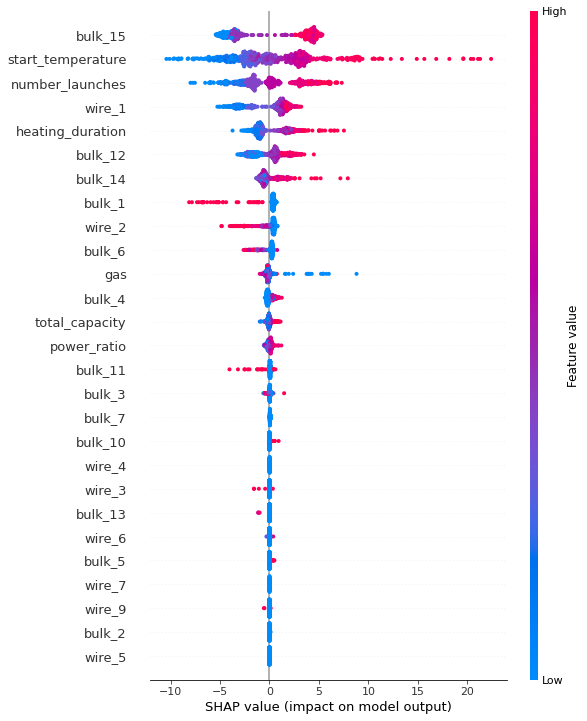

In [105]:
# График визуализации вклада признаков в каждое предсказание модели 
#(Слева что снизилась а справа что Уровень остался прежнем)
shap.plots.beeswarm(shap_values, max_display=30)

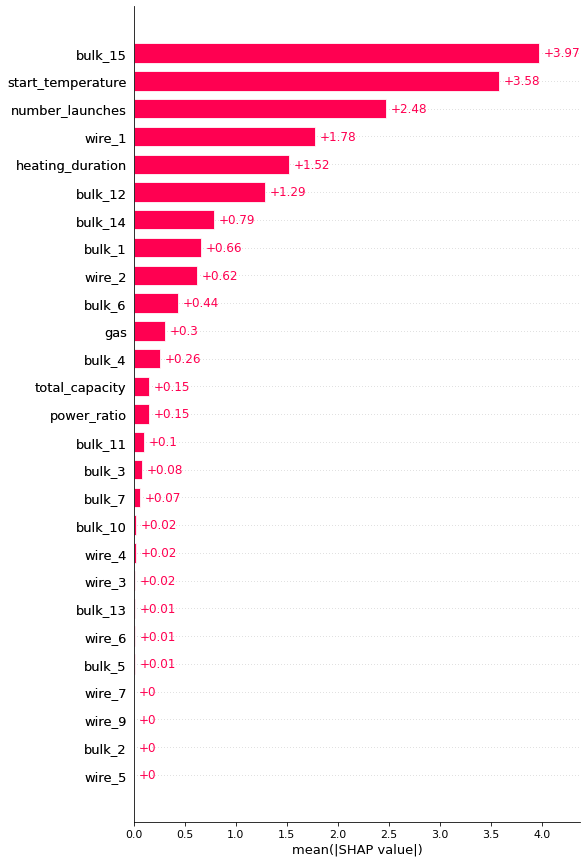

In [106]:
# График отражающий общий вклад признаков в прогнозы модели
shap.plots.bar(shap_values, max_display=30)

**<span style='color:green'>Мини вывод:</span>**

- Признаками с высокими пропусками сыграли свою роль помащь в их полезности нуливая
- В топ 3 входят 'start_temperature', 'bulk_15', 'number_launches'
- Также можно утверждать что новые созданые признаки были сдела незря хоть какую пользу они приносят
- Возможно стоит поработать в создание новых признаков в итоговой таблице

## Задача: Анализ одного из важных признаков.

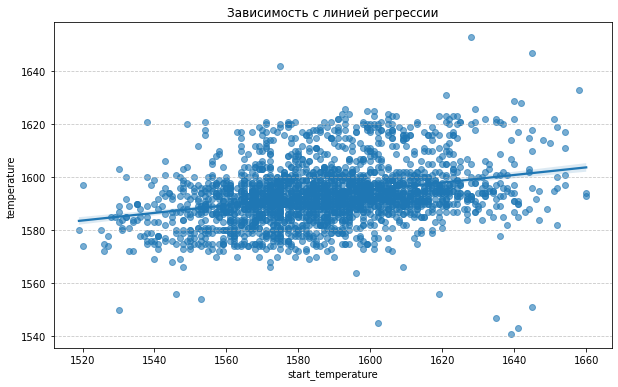

In [107]:
# Строю график
plt.figure(figsize=(10, 6))
sns.regplot(x=request_response['start_temperature'], y=request_response[target_attribute], scatter_kws={'alpha':0.6})
plt.title('Зависимость с линией регрессии')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

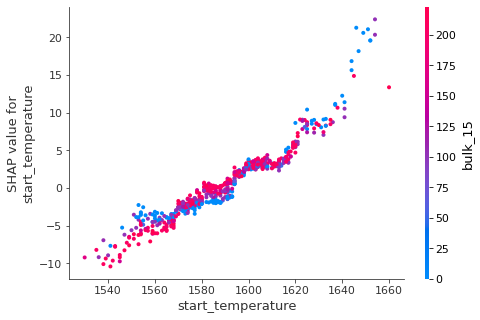

In [108]:
# Строим график зависимости для конкретного признака
shap.dependence_plot('start_temperature', shap_values.values, X_test)

**<span style='color:Orange'>Описание метода оценивания:</span>**

- По горизонтали отложены реальные значения признака [start_temperature]
- По вертикали — вклад этого признака в предсказание модели (SHAP‑значение)
- Положительные значения увеличивают прогноз, отрицательные — уменьшают».

**<span style='color:green'>Мини вывод:</span>**

- Основной определяющей тепрературой формируются вокруг `1580`
- Меньше `1560` и `1620` начинается разброс и он увеличивается если показатели увелличиваются или уменьшаются
- Видно что точки выстроены в линию стремящиюся вверх
- Получается нужно стремиться к тепмературе между [1560 - 1620] для лучшего предсказания

# <span style='color:RoyalBlue'>Итоговые выводы</span>

## <span style='font-size: 18px;color: black'>**Описание лучшей модели.**</span>

In [110]:
# Вывод параметров лучшеймодели по метрике MAE
rating_table.parameters_of_the_best_model('CatBoostRegressor')

Параметры Лучшей модели:
  n_estimators: 299
  learning_rate: 0.03140780323514616
  depth: 6
  l2_leaf_reg: 5.332461363513219
  bagging_temperature: 0.7970059828253072
  random_strength: 0.1471024594001702
  grow_policy: Lossguide
По метрике MAE лучшей модели на обучающих данных: 6.6907


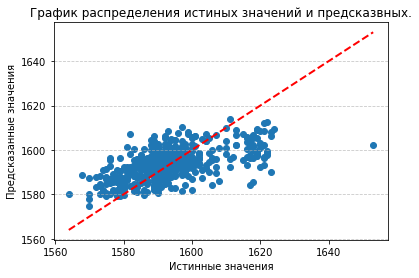

In [111]:
# Сравнения предсказаных и истиными значенияями
rating_table.chart_true_vs_predicted('CatBoostRegressor')

<span style='font-size:18px'>

- Был достигнут целевой результат обученых моделей
- Лучшая по метрике оказалась `CatBoostRegressor`
- Также лучшая модель оказалась лучше константной
- Скопление точек в одной области и разреженность в другой указывает на неравномерную точность модели
- Также наблюдаю о наличие в данных выбросах как видно по удалёных точках на графике
- Получается модель неявляется эталоном и поэтому её можно ещё улучшеть!!!

## <span style='font-size: 18px;color: black'>**Предложения по улучшить модель.**</span>

<span style='font-size:18px'>

- Усложнить модель PyTorch и обучить на большем времени
- Уделить больше времени созданию новых признаков или дополнить новыми
- Можно дополнить времеными рядами для лучшего обучения
- Превести к чёткой структуре с пояснениями, Измерениями еденицах, пределы и т.д.

## <span style='font-size: 18px;color: black'>**Бизнес-рекомендации.**</span>

<span style='font-size:18px'>

- Лучше следить за представляемыми данными особенно рисковаными которые могут подорвать репутацию компании;
- Выстроить процес до идеала как в `McDonald’s` где чётка идёт налаженый процес таким образом
можно уменьшить потребления энергии и телодвижений;
- Можно устроить Хакатон по улучшению или экономически выгодой среди участниками с презывым фондом.